<a href="https://colab.research.google.com/github/BrajanNieto/RiskAnalysis/blob/main/MonteCarloDamExample-BrajanNieto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
Dam Construction Schedule Simulator
----------------------------------------------------------------
Este notebook acompaña al script de simulación de cronograma de presa
utilizando Monte Carlo y restricciones geométricas de estabilidad.

**Objetivos del Notebook**:
1. **Presentación interactiva** de la lógica de simulación paso a paso.
2. Ejemplificar las **distribuciones Beta‑PERT** para modelar rendimientos.
3. Visualizar resultados en tiempo real (gráficas, tablas) y analizar:
   - Curvas de avance de altura para CURB, CORE y MAT4.
   - Volúmenes diarios, promedios, percentiles.
4. Discusión teórica sobre las **restricciones de altura** en presas de relaves.

---

### Teoría de las restricciones de altura (Δh)
Al construir presas de relaves o estructuras de enrocado:
- **Diferencias de altura** excesivas entre materiales generan inestabilidad.
- **CURB** (hormigón escalonado) se usa para impermeabilizar y debe mantenerse
  cerca del **núcleo (CORE)** para:
  - Evitar deslizamientos entre zonas flexibles (enrocado) y rígidas (hormigón).
  - Controlar la presión hidrostática y minimizar filtraciones.
- **MAT4** (enrocado masivo) aporta estabilidad de banco ancho, pero si avanza
  demasiado se desestabiliza el corte en la zona interna.

Por ello imponemos:
```
  CURB – CORE  ∈ [−10 m, +5 m]
  MAT4 – CORE ∈ [−5 m, +10 m]
```
que aseguran que ningún frente sobresalga en exceso y se conserve un talud
seguro y continuo.

### Estructura del Notebook
1. **Importación de librerías**: NumPy, Pandas, Matplotlib.
2. **Carga de datos**: `data.csv` con volúmenes por cota.
3. **Definición de funciones**:
   - `beta_pert_sample()`: muestreo de distribuciones Beta‑PERT.
   - `simulate()`: bucle diario con muestreo, chequeo de Δh y actualización de estado.
4. **Parámetros de simulación**:
   - `--runs`: número de iteraciones (Monte Carlo).
   - `--no-beta`: modo determinista.
   - `--delta-h`: personalización de límites.
5. **Ejecución**:
   - Registro de alturas y volúmenes diarios.
   - Agrupación de resultados y cálculo de medias.
6. **Visualización**:
   - Gráficas de altura vs. día.
   - Volumen diario por frente (barras y medias).
   - Percentiles (opcional).

Al final, obtenemos insights sobre el ritmo de construcción, posibles cuellos
de botella y un análisis de riesgos basado en probabilidad.

---

In [ ]:
"""
Dam construction schedule simulator (Three‐front version, CURB corrected)
-----------------------------------------------------------------------
Lee los volúmenes por cota desde **data.csv** (separador `;`) y simula,
día a día, la construcción de tres frentes independientes:

* **CURB** – Concreto escalonado impermeable
* **CORE** – Materiales 1 + 2 + 3 que crecen juntos
* **MAT4** – Enrocado masivo

### Restricciones de altura (asimétricas)
*   `CURB − CORE ≤ +5 m`  (CURB no más de 5 m sobre CORE)
*   `CURB − CORE ≥ −10 m` (CORE puede superar a CURB hasta 10 m)
*   `MAT4 − CORE ≤ +10 m` (MAT4 no más de 10 m sobre CORE)
*   `MAT4 − CORE ≥ −5 m`  (CORE puede superar a MAT4 hasta 5 m)

### Rendimientos diarios (m³/día) · Beta‑PERT
*   CURB : 500 / 400 / 300
*   CORE : 2100 / 1800 / 1350
*   MAT4 : 2300 / 2000 / 1600

### Uso
```bash
python dam_schedule_sim.py            # Monte Carlo (Beta‑PERT)
python dam_schedule_sim.py --no-beta  # Determinista (most likely)
python dam_schedule_sim.py --delta-h 6 12 8 4  # Cambia límites
```

Genera:
* **daily_heights.csv** – cota de cada frente por día
* **daily_volumes.csv** – m³ colocados por día
"""

from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Parámetros por defecto
# ------------------------------------------------------------
DATA_FILE = "data.csv"  # archivo de entrada (delimiter=';')
SEED = 42

PROD_PARAMS: Dict[str, Dict[str, float]] = {
    "curb": {"optimistic": 500, "most_likely": 400, "pessimistic": 300},
    "core": {"optimistic": 2100, "most_likely": 1800, "pessimistic": 1350},
    "mat4": {"optimistic": 2300, "most_likely": 2000, "pessimistic": 1600},
}

# Límites de diferencia: (máx sobre CORE, mín sobre CORE)
DELTA_H_DEFAULT = {
    "curb": (+5.0, -10.0),
    "mat4": (+10.0, -5.0),
}

# ------------------------------------------------------------
# Utilidades
# ------------------------------------------------------------

def beta_pert_sample(a: float, b: float, m: float, lamb: float = 4.0) -> float:
    """Una muestra Beta‑PERT escalada a [a, b]."""
    if a == b:
        return a
    alpha = 1 + lamb * (m - a) / (b - a)
    beta = 1 + lamb * (b - m) / (b - a)
    return a + np.random.beta(alpha, beta) * (b - a)


def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """Carga CSV separado por ‘;’ y asegura columnas requeridas."""
    df = pd.read_csv(path, delimiter=';')
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3", "Material4"}
    if not expected.issubset(df.columns):
        raise ValueError(f"El archivo {path} debe contener columnas: {expected}")

    df["Core"] = df[["Material1", "Material2", "Material3"]].sum(axis=1)
    return df[["Cota", "Curb", "Core", "Material4"]].rename(columns={"Material4": "Mat4"})


@dataclass
class FrontState:
    row_idx: int
    vol_left: float
    height: float


# ------------------------------------------------------------
# Simulador
# ------------------------------------------------------------

def simulate(df: pd.DataFrame, delta_h: Dict[str, Tuple[float, float]], *, use_beta: bool = True,
             seed: int = SEED) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Devuelve (heights_df, volumes_df)."""
    np.random.seed(seed)

    cotas = df["Cota"].values
    vol_curb = df["Curb"].values
    vol_core = df["Core"].values
    vol_mat4 = df["Mat4"].values
    n_rows = len(df)

    fronts = {
        "curb": FrontState(0, vol_curb[0], cotas[0]),
        "core": FrontState(0, vol_core[0], cotas[0]),
        "mat4": FrontState(0, vol_mat4[0], cotas[0]),
    }

    heights_rec: List[Tuple[int, float, float, float]] = []  # Dia, h_curb, h_core, h_mat4
    volumes_rec: List[Tuple[int, float, float, float]] = []  # Dia, v_curb, v_core, v_mat4

    dia = 0
    while any(fs.row_idx < n_rows for fs in fronts.values()):
        # 1  Rendimientos diarios
        prod = {}
        for k, fs in fronts.items():
            pp = PROD_PARAMS[k]
            prod[k] = beta_pert_sample(pp["pessimistic"], pp["optimistic"], pp["most_likely"]) if use_beta else pp["most_likely"]

        # 2  Restricciones respecto al CORE
        diff_curb_core = fronts["curb"].height - fronts["core"].height
        diff_mat4_core = fronts["mat4"].height - fronts["core"].height

        allow = {"curb": True, "core": True, "mat4": True}
        curb_up, curb_down = delta_h["curb"]
        m4_up, m4_down = delta_h["mat4"]

        if diff_curb_core > curb_up:
            allow["curb"] = False
        if diff_curb_core < curb_down:
            allow["core"] = False
        if diff_mat4_core > m4_up:
            allow["mat4"] = False
        if diff_mat4_core < m4_down:
            allow["core"] = False

        # 3  Colocación
        placed = {"curb": 0.0, "core": 0.0, "mat4": 0.0}
        for k in ["curb", "core", "mat4"]:
            fs = fronts[k]
            if allow[k] and fs.row_idx < n_rows and fs.vol_left > 0:
                to_place = min(prod[k], fs.vol_left)
                placed[k] = to_place

                total_row_vol = (
                    df.iloc[fs.row_idx]["Curb"] if k == "curb" else
                    df.iloc[fs.row_idx]["Core"] if k == "core" else
                    df.iloc[fs.row_idx]["Mat4"]
                )
                fs.height += to_place / total_row_vol  # incremento proporcional a 1 m
                fs.vol_left -= to_place

                if fs.vol_left <= 1e-6:  # cota completada
                    fs.row_idx += 1
                    if fs.row_idx < n_rows:
                        fs.vol_left = (
                            df.iloc[fs.row_idx]["Curb"] if k == "curb" else
                            df.iloc[fs.row_idx]["Core"] if k == "core" else
                            df.iloc[fs.row_idx]["Mat4"]
                        )
                        fs.height = cotas[fs.row_idx]

        heights_rec.append((dia, fronts["curb"].height, fronts["core"].height, fronts["mat4"].height))
        volumes_rec.append((dia, placed["curb"], placed["core"], placed["mat4"]))

        dia += 1
        if dia > 100_000:
            raise RuntimeError("Simulación superó 100 000 días – verifica datos y límites de ∆h.")

    heights_df = pd.DataFrame(heights_rec, columns=["Dia", "H_CURB", "H_CORE", "H_MAT4"])
    volumes_df = pd.DataFrame(volumes_rec, columns=["Dia", "V_CURB", "V_CORE", "V_MAT4"])
    return heights_df, volumes_df


# ------------------------------------------------------------
# Línea de comandos
# ------------------------------------------------------------

def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--no-beta", action="store_true", help="Usa rendimientos *most likely* en lugar de Beta‑PERT")
    parser.add_argument("--delta-h", nargs=4, type=float, metavar=("CURB_UP", "CURB_DOWN", "M4_UP", "M4_DOWN"),
                        help="Sobrescribe los cuatro límites de altura")
    #args = parser.parse_args()
    args, unknown = parser.parse_known_args()
    df = load_data()
    delta_h = DELTA_H_DEFAULT.copy()
    if args.delta_h:
        delta_h["curb"] = (args.delta_h[0], -abs(args.delta_h[1]))
        delta_h["mat4"] = (args.delta_h[2], -abs(args.delta_h[3]))

    heights_df, volumes_df = simulate(df, delta_h, use_beta=not args.no_beta)

    heights_df.to_csv("daily_heights.csv", index=False)
    volumes_df.to_csv("daily_volumes.csv", index=False)

    print("Simulación completada – salidas: daily_heights.csv y daily_volumes.csv")
    print(heights_df.head(50))


if __name__ == "__main__":
    main()


Simulación completada – salidas: daily_heights.csv y daily_volumes.csv
    Dia       H_CURB  H_CORE       H_MAT4
0     0  4500.209281  4501.0  4501.000000
1     1  4500.394320  4502.0  4501.613985
2     2  4500.615962  4503.0  4502.000000
3     3  4500.833253  4504.0  4502.908233
4     4  4501.000000  4505.0  4503.000000
5     5  4502.000000  4506.0  4503.496749
6     6  4503.000000  4507.0  4503.979152
7     7  4504.000000  4508.0  4504.000000
8     8  4505.000000  4509.0  4504.678556
9     9  4506.000000  4510.0  4505.000000
10   10  4507.000000  4511.0  4506.000000
11   11  4508.000000  4512.0  4506.483639
12   12  4509.000000  4512.0  4506.969670
13   13  4510.000000  4512.0  4507.000000
14   14  4511.000000  4513.0  4507.965777
15   15  4511.203174  4513.0  4508.000000
16   16  4511.419796  4514.0  4508.101562
17   17  4511.628386  4514.0  4508.193992
18   18  4511.850247  4514.0  4508.288476
19   19  4512.000000  4514.0  4508.395848
20   20  4513.000000  4514.0  4508.494848
21   

In [ ]:
"""
Dam construction schedule simulator – Multi‑run version
-------------------------------------------------------
Lee los volúmenes por cota desde **data.csv** (sep. `;`) y simula
la construcción de tres frentes (CURB, CORE, MAT4) cumpliendo
restricciones de altura.

* `--runs N` Número de corridas Monte Carlo (default = 1 → modo determinista).
* `--no-beta` Ignora la distribución Beta‑PERT y usa los valores *most likely*.
* `--delta-h CU CD MU MD` Sobrescribe los cuatro límites ∆h.

Salidas:
* `daily_heights.csv` Resultados de la **primera** corrida (útil para debug).
* `daily_volumes.csv` Idem para volúmenes.
* `daily_heights_mean.csv` Promedio de alturas (si `--runs > 1`).
* `daily_volumes_mean.csv` Promedio de volúmenes (si `--runs > 1`).
"""

from __future__ import annotations

import argparse
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────
# Parámetros por defecto
# ────────────────────────────────────────────────────────────
DATA_FILE = "data.csv"
SEED = 42
PROD_PARAMS: Dict[str, Dict[str, float]] = {
    "curb": {"optimistic": 500,  "most_likely": 400,  "pessimistic": 300},
    "core": {"optimistic": 2100, "most_likely": 1800, "pessimistic": 1350},
    "mat4": {"optimistic": 2300, "most_likely": 2000, "pessimistic": 1600},
}
DELTA_H_DEFAULT: Dict[str, Tuple[float, float]] = {
    "curb": (+5.0, -10.0),  # (máx sobre CORE, mín sobre CORE)
    "mat4": (+10.0, -5.0),
}

# ────────────────────────────────────────────────────────────
# Utilidades
# ────────────────────────────────────────────────────────────

def beta_pert_sample(a: float, b: float, m: float, lamb: float = 4.0) -> float:
    """Una muestra Beta‑PERT escalada a [a, b]."""
    if a == b:
        return a
    alpha = 1 + lamb * (m - a) / (b - a)
    beta = 1 + lamb * (b - m) / (b - a)
    return a + np.random.beta(alpha, beta) * (b - a)


def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """Carga CSV y crea columna Core."""
    df = pd.read_csv(path, delimiter=';')
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3", "Material4"}
    if not expected.issubset(df.columns):
        raise ValueError(f"{path} debe contener columnas: {expected}")
    df["Core"] = df[["Material1", "Material2", "Material3"]].sum(axis=1)
    return df[["Cota", "Curb", "Core", "Material4"]].rename(columns={"Material4": "Mat4"})


@dataclass
class FrontState:
    row_idx: int
    vol_left: float
    height: float

# ────────────────────────────────────────────────────────────
# Simulación de UNA corrida
# ────────────────────────────────────────────────────────────

def simulate(df: pd.DataFrame, delta_h: Dict[str, Tuple[float, float]], *, use_beta: bool, rnd_seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    np.random.seed(rnd_seed)

    cotas = df["Cota"].values
    vols = {
        "curb": df["Curb"].values,
        "core": df["Core"].values,
        "mat4": df["Mat4"].values,
    }
    fronts = {k: FrontState(0, vols[k][0], cotas[0]) for k in vols}

    heights_rec: List[Tuple[int, float, float, float]] = []
    volumes_rec: List[Tuple[int, float, float, float]] = []

    dia = 0
    while any(fs.row_idx < len(cotas) for fs in fronts.values()):
        # 1. Rendimientos diarios
        prod = {}
        for k in fronts:
            p = PROD_PARAMS[k]
            prod[k] = beta_pert_sample(p["pessimistic"], p["optimistic"], p["most_likely"]) if use_beta else p["most_likely"]

        # 2. Restricciones ∆h respecto al CORE
        diff_curb_core = fronts["curb"].height - fronts["core"].height
        diff_mat4_core = fronts["mat4"].height - fronts["core"].height

        allow = {"curb": True, "core": True, "mat4": True}
        curb_up, curb_down = delta_h["curb"]
        mat4_up, mat4_down = delta_h["mat4"]

        if diff_curb_core > curb_up:
            allow["curb"] = False
        if diff_curb_core < curb_down:
            allow["core"] = False
        if diff_mat4_core > mat4_up:
            allow["mat4"] = False
        if diff_mat4_core < mat4_down:
            allow["core"] = False

        # 3. Colocación de material
        placed = {"curb": 0.0, "core": 0.0, "mat4": 0.0}
        for k, fs in fronts.items():
            if allow[k] and fs.row_idx < len(cotas) and fs.vol_left > 0:
                vol_row = vols[k][fs.row_idx]
                x = min(prod[k], fs.vol_left)
                placed[k] = x
                fs.height += x / vol_row  # incremento proporcional (1 m completo = vol_row)
                fs.vol_left -= x
                if fs.vol_left <= 1e-6:  # cota completada
                    fs.row_idx += 1
                    if fs.row_idx < len(cotas):
                        fs.vol_left = vols[k][fs.row_idx]
                        fs.height = cotas[fs.row_idx]

        heights_rec.append((dia, fronts["curb"].height, fronts["core"].height, fronts["mat4"].height))
        volumes_rec.append((dia, placed["curb"], placed["core"], placed["mat4"]))

        dia += 1
        if dia > 100_000:
            raise RuntimeError("Simulación >100 000 días – verifica datos o ∆h.")

    hdf = pd.DataFrame(heights_rec, columns=["Dia", "H_CURB", "H_CORE", "H_MAT4"])
    vdf = pd.DataFrame(volumes_rec, columns=["Dia", "V_CURB", "V_CORE", "V_MAT4"])
    return hdf, vdf


# ────────────────────────────────────────────────────────────
# Función principal
# ────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--runs", type=int, default=1, help="Número de corridas Monte Carlo (default=1)")
    parser.add_argument("--no-beta", action="store_true", help="Usa rendimientos *most likely* en lugar de Beta‑PERT")
    parser.add_argument("--delta-h", nargs=4, type=float, metavar=("CURB_UP", "CURB_DOWN", "M4_UP", "M4_DOWN"),
                        help="Sobrescribe los cuatro límites de altura")
    #args = parser.parse_args()
    #args = parser.parse_args()
    args, unknown = parser.parse_known_args()

    # 1. Datos y parámetros
    df = load_data()
    delta_h = DELTA_H_DEFAULT.copy()
    if args.delta_h:
        delta_h["curb"] = (args.delta_h[0], -abs(args.delta_h[1]))
        delta_h["mat4"] = (args.delta_h[2], -abs(args.delta_h[3]))

    runs = max(1, args.runs)
    use_beta = not args.no_beta

    heights_runs: List[pd.DataFrame] = []
    volumes_runs: List[pd.DataFrame] = []

    # 2. Ejecutar N corridas
    for i in range(runs):
        h, v = simulate(df, delta_h, use_beta=use_beta, rnd_seed=SEED + i)
        heights_runs.append(h)
        volumes_runs.append(v)
        if i == 0:  # guardamos la primera corrida para inspección
            h.to_csv("daily_heights.csv", index=False)
            v.to_csv("daily_volumes.csv", index=False)

    print(f"Se completaron {runs} corrida(s). Resultados de la primera ⇒ daily_heights.csv / daily_volumes.csv")

    # 3. Promediar si hay más de una corrida
    if runs > 1:
        heights_mean = pd.concat(heights_runs).groupby("Dia").mean().reset_index()
        volumes_mean = pd.concat(volumes_runs).groupby("Dia").mean().reset_index()
        heights_mean.to_csv("daily_heights_mean.csv", index=False)
        volumes_mean.to_csv("daily_volumes_mean.csv", index=False)
        print("Medias guardadas ⇒ daily_heights_mean.csv / daily_volumes_mean.csv")


if __name__ == "__main__":
    main()


Se completaron 1 corrida(s). Resultados de la primera ⇒ daily_heights.csv / daily_volumes.csv


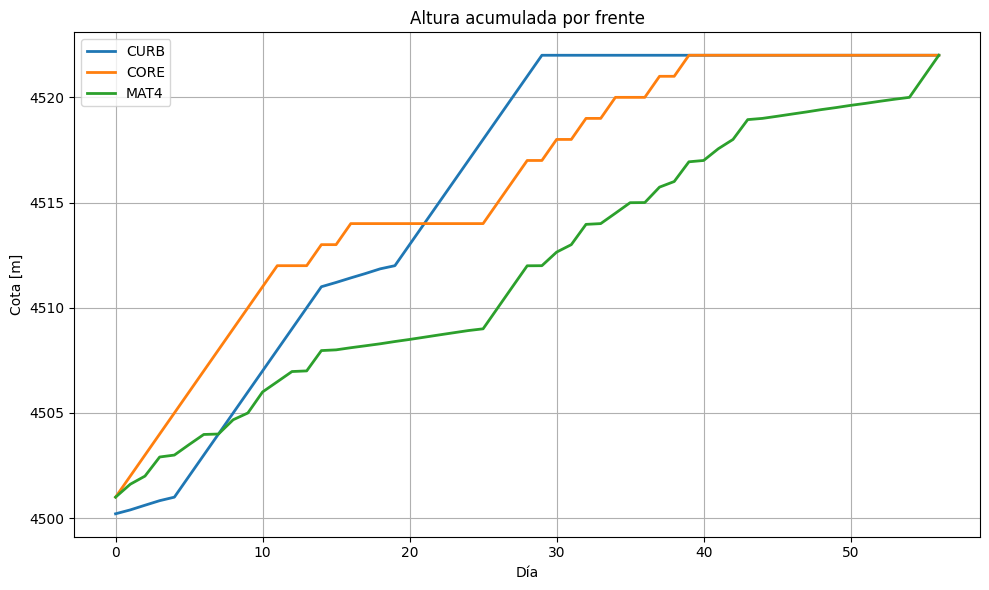

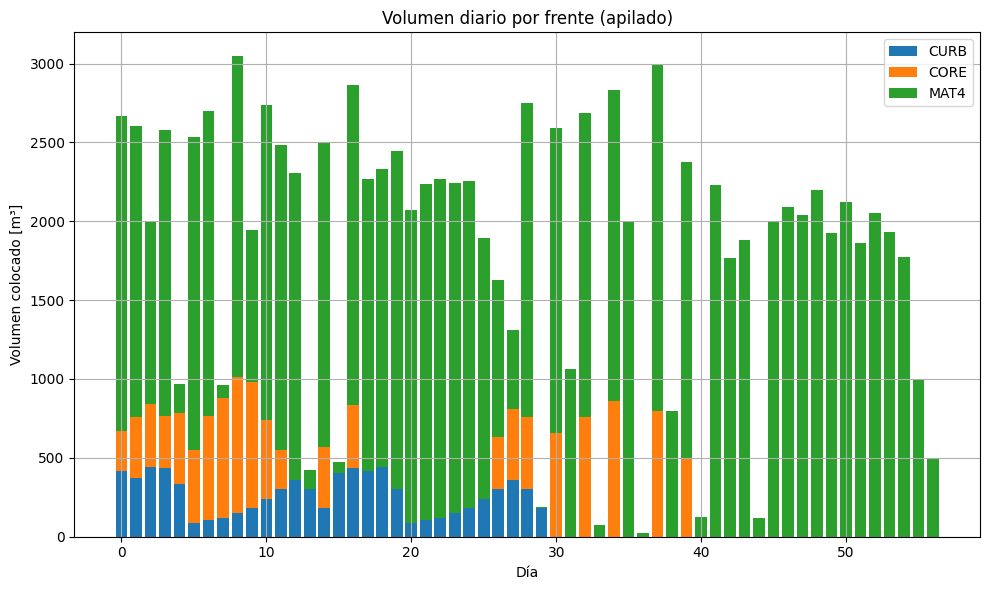

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los resultados
heights = pd.read_csv('daily_heights.csv')    # columnas: Dia, H_CURB, H_CORE, H_MAT4
volumes = pd.read_csv('daily_volumes.csv')    # columnas: Dia, V_CURB, V_CORE, V_MAT4

# 2. Gráfica de alturas acumuladas
plt.figure(figsize=(10, 6))
plt.plot(heights['Dia'], heights['H_CURB'], label='CURB',    linewidth=2)
plt.plot(heights['Dia'], heights['H_CORE'], label='CORE',    linewidth=2)
plt.plot(heights['Dia'], heights['H_MAT4'], label='MAT4',    linewidth=2)
plt.xlabel('Día')
plt.ylabel('Cota [m]')
plt.title('Altura acumulada por frente')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Gráfica de volumen colocado por día (barras apiladas)
plt.figure(figsize=(10, 6))
plt.bar(volumes['Dia'], volumes['V_CURB'], label='CURB')
plt.bar(volumes['Dia'], volumes['V_CORE'], bottom=volumes['V_CURB'], label='CORE')
bottom_stack = volumes['V_CURB'] + volumes['V_CORE']
plt.bar(volumes['Dia'], volumes['V_MAT4'], bottom=bottom_stack, label='MAT4')
plt.xlabel('Día')
plt.ylabel('Volumen colocado [m³]')
plt.title('Volumen diario por frente (apilado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
heights = pd.read_csv('daily_heights.csv')    # Dia, H_CURB, H_CORE, H_MAT4
volumes = pd.read_csv('daily_volumes.csv')    # Dia, V_CURB, V_CORE, V_MAT4

# 2. Gráfica de alturas acumuladas (líneas)
plt.figure(figsize=(10, 6))
plt.plot(heights['Dia'], heights['H_CURB'], label='CURB',   linewidth=2)
plt.plot(heights['Dia'], heights['H_CORE'], label='CORE',   linewidth=2)
plt.plot(heights['Dia'], heights['H_MAT4'], label='MAT4',   linewidth=2)
plt.xlabel('Día')
plt.ylabel('Cota [m]')
plt.title('Altura acumulada por frente')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Gráfica de volumen diario por frente (barras agrupadas + medias)
dias = volumes['Dia'].values
bar_width = 0.25
x = np.arange(len(dias))

# Valores
v_curb = volumes['V_CURB'].values
v_core = volumes['V_CORE'].values
v_mat4 = volumes['V_MAT4'].values

# Crear barras agrupadas
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, v_curb,  width=bar_width, label='CURB')
plt.bar(x,               v_core, width=bar_width, label='CORE')
plt.bar(x + bar_width,   v_mat4, width=bar_width, label='MAT4')

# Líneas punteadas de media
mean_curb = v_curb.mean()
mean_core = v_core.mean()
mean_mat4 = v_mat4.mean()
plt.hlines(mean_curb, x.min() - bar_width, x.max() + bar_width,
           colors='C0', linestyles='--', label=f'μ CURB = {mean_curb:.1f}')
plt.hlines(mean_core, x.min() - bar_width, x.max() + bar_width,
           colors='C1', linestyles='--', label=f'μ CORE = {mean_core:.1f}')
plt.hlines(mean_mat4, x.min() - bar_width, x.max() + bar_width,
           colors='C2', linestyles='--', label=f'μ MAT4 = {mean_mat4:.1f}')

# Ajustes finales
plt.xticks(x, dias)
plt.xlabel('Día')
plt.ylabel('Volumen colocado [m³]')
plt.title('Volumen diario por frente (barras agrupadas)')
plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


KeyError: 'H_CURB'

<Figure size 1000x600 with 0 Axes>

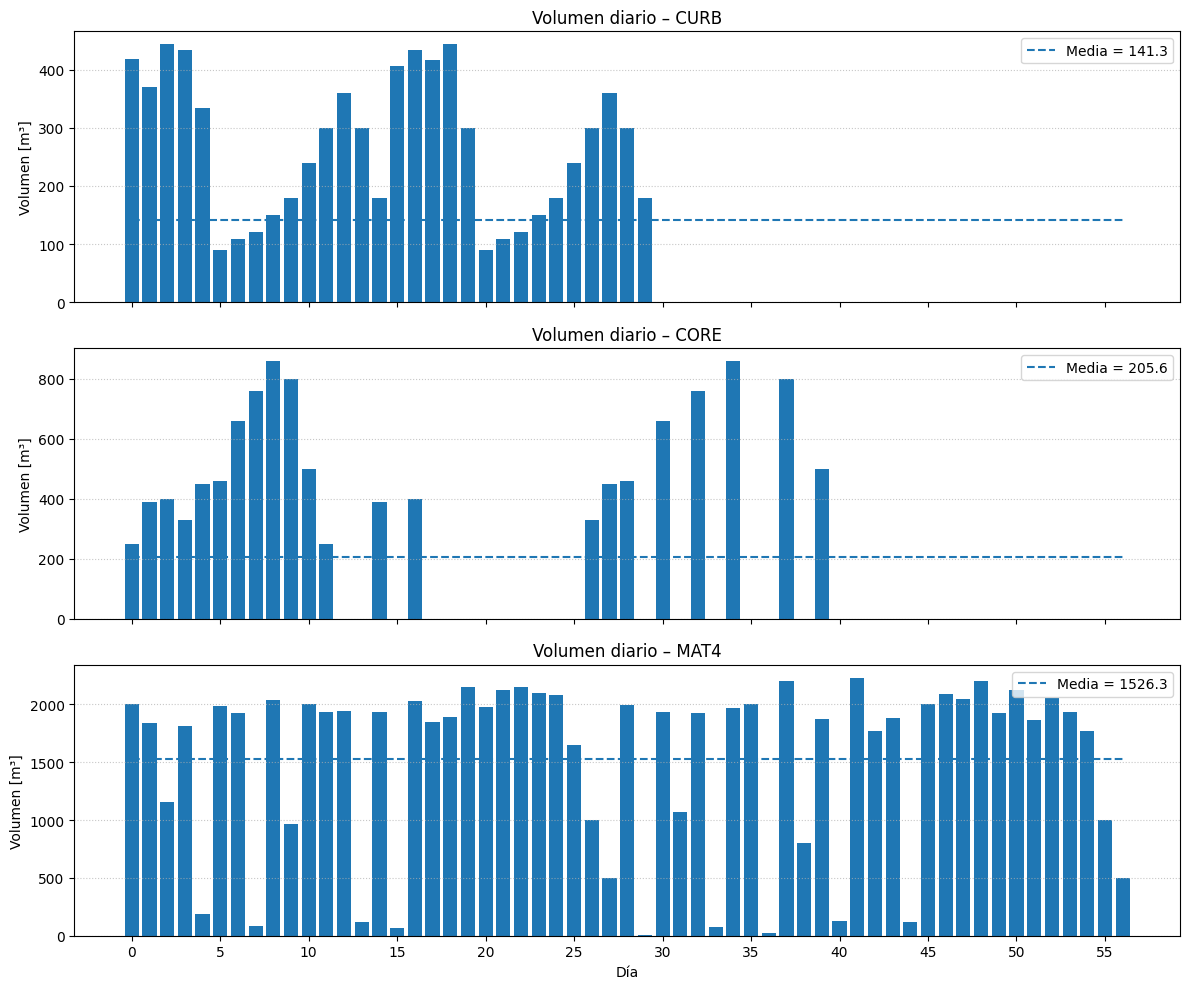

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
vol = pd.read_csv('daily_volumes.csv')  # Dia, V_CURB, V_CORE, V_MAT4

# Configuración de ejes
dias = vol['Dia']
max_dia = dias.max()
xticks = np.arange(0, max_dia+1, 5)

# Diccionario para iterar
series = {
    'CURB': 'V_CURB',
    'CORE': 'V_CORE',
    'MAT4': 'V_MAT4'
}

# Crear subplots: 3 filas x 1 columna
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, (name, col) in zip(axes, series.items()):
    y = vol[col]
    ax.bar(dias, y, width=0.8)
    # Línea media
    mean = y.mean()
    ax.hlines(mean, 0, max_dia, linestyles='--', label=f'Media = {mean:.1f}')
    # Etiquetas y estilo
    ax.set_ylabel('Volumen [m³]')
    ax.set_title(f'Volumen diario – {name}')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.7)

# Ajustes del eje x
axes[-1].set_xlabel('Día')
axes[-1].set_xticks(xticks)
plt.tight_layout()
plt.show()


KeyError: 'V_CURB'

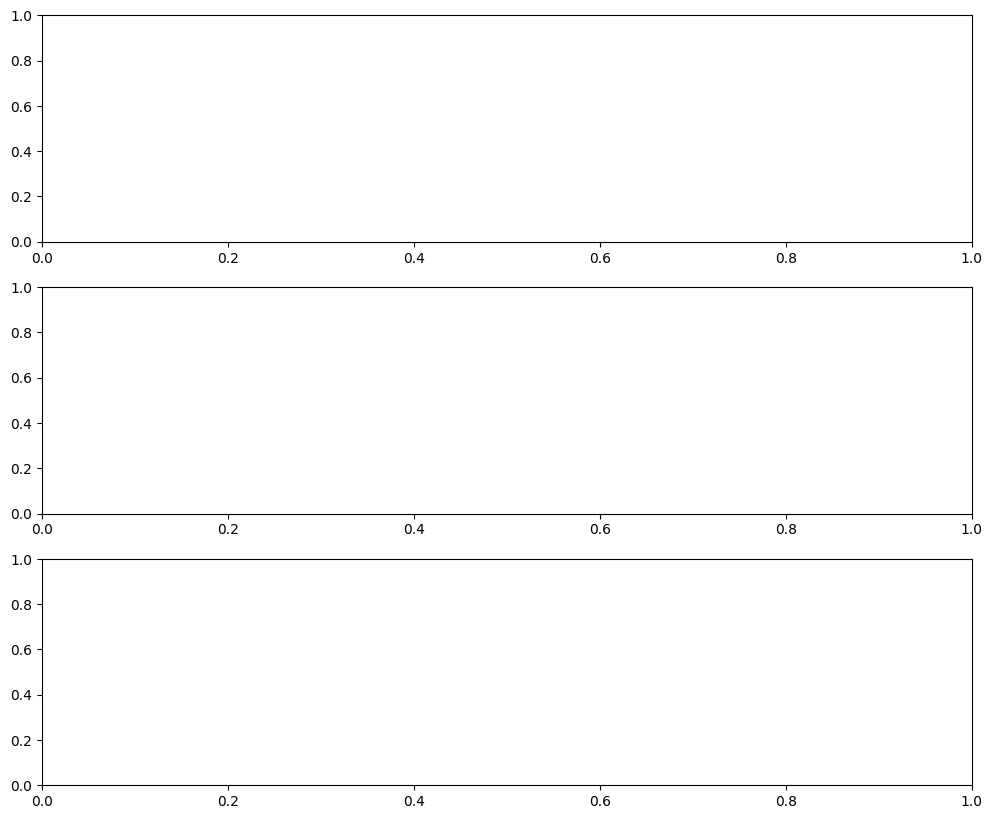

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
vol = pd.read_csv('daily_volumes.csv')  # columnas: Dia, V_CURB, V_CORE, V_MAT4

# Configuración de ejes
max_dia = vol['Dia'].max()
xticks = np.arange(0, max_dia+1, 10)

# Mapeo de series
series = {
    'CURB': 'V_CURB',
    'CORE': 'V_CORE',
    'MAT4': 'V_MAT4'
}

# Crear subplots: 3 filas x 1 columna, sin sharex para mostrar etiquetas en cada uno
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, (name, col) in zip(axes, series.items()):
    y = vol[col]
    ax.bar(vol['Dia'], y, width=0.8)
    # Línea de media
    mean = y.mean()
    ax.hlines(mean, 0, max_dia, linestyles='--', label=f'Media = {mean:.1f}')
    # Etiquetas y estilo
    ax.set_ylabel('Volumen [m³]')
    ax.set_title(f'Volumen diario – {name}')
    ax.set_xticks(xticks)
    ax.set_xlabel('Día')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple, List

# -----------------------------
# Config
# -----------------------------
DATA_FILE = "data.csv"
SEED = 42

# Materials (internal names) and CSV column mapping
MATERIALS = ["curb", "mat1", "mat2", "mat3"]
CSV_COLS = {"curb": "Curb", "mat1": "Material1", "mat2": "Material2", "mat3": "Material3"}
IDX = {m: i for i, m in enumerate(MATERIALS)}
N = len(MATERIALS)

# Tensor 3D of constraints: constraints[i,j,0]=min; constraints[i,j,1]=max
# Constraint is on (hi - hj)
CONSTRAINTS = np.full((N, N, 2), np.nan)
CONSTRAINTS[IDX['curb'], IDX['mat1'], :] = [-1.10, -0.55]   # curb below mat1 by [0.55, 1.10] m
CONSTRAINTS[IDX['mat1'], IDX['mat2'], :] = [-1.10,  0.00]   # mat1 0..1.10 m below mat2
CONSTRAINTS[IDX['mat3'], IDX['mat2'], :] = [-3.00,  3.00]   # mat3 ±3 m vs mat2

# PERT Beta parameters (m^3/day)
PERF_PARAMS = {
    "curb": {"optimistic": 200,   "most_likely": 170,  "pessimistic": 140},
    "mat1": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat2": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat3": {"optimistic": 24000, "most_likely": 21000,"pessimistic": 20000},
}

# -----------------------------
# Data loading & interpolation
# -----------------------------
def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """
    Load CSV, validate columns, sort by Cota ascending, reset index.
    Expected columns: Cota, Curb, Material1, Material2, Material3
    """
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3"}
    df = pd.read_csv(path, delimiter=";")
    if not expected.issubset(df.columns):
        raise ValueError(f"{path} debe contener las columnas: {expected}")
    df = df.sort_values("Cota").reset_index(drop=True)
    return df

def build_interpolators(df: pd.DataFrame):
    """
    Build forward (height->volume) and inverse (volume->height) interpolators
    using numpy.interp for each material. Assumes cumulative volumes increasing with Cota.
    """
    H = df["Cota"].to_numpy()

    vols_by_mat = {m: df[CSV_COLS[m]].to_numpy() for m in MATERIALS}
    Hmin, Hmax = H[0], H[-1]
    Vmin = {m: vols_by_mat[m][0] for m in MATERIALS}
    Vmax = {m: vols_by_mat[m][-1] for m in MATERIALS}

    # Optional sanity check: monotonic non-decreasing volumes
    for m in MATERIALS:
        if np.any(np.diff(vols_by_mat[m]) < -1e-9):
            raise ValueError(f"El volumen acumulado de {m} no es monótono creciente con la cota.")

    def vol_at_height(m: str, h: float) -> float:
        # Clamp to [Hmin, Hmax] implicitly via left/right in interp
        return float(np.interp(h, H, vols_by_mat[m], left=vols_by_mat[m][0], right=vols_by_mat[m][-1]))

    def height_at_volume(m: str, v: float) -> float:
        # Clamp to [Vmin, Vmax] implicitly via left/right in interp
        return float(np.interp(v, vols_by_mat[m], H, left=H[0], right=H[-1]))

    return (vol_at_height, height_at_volume, Hmin, Hmax, Vmin, Vmax)

# -----------------------------
# Performance sampling (PERT)
# -----------------------------
def compute_pert_alpha_beta(opt: float, mode: float, pes: float) -> Tuple[float, float]:
    """Compute α and β for PERT Beta."""
    if pes <= opt:
        raise ValueError("PERT params must satisfy pessimistic > optimistic.")
    alpha = 1.0 + 4.0 * (mode - opt) / (pes - opt)
    beta  = 1.0 + 4.0 * (pes - mode) / (pes - opt)
    return alpha, beta

def sample_performance(material: str, rng: np.random.Generator, stochastic: bool = True) -> float:
    """
    Return daily production (m^3/day) for a material:
    - If stochastic=True: sample from PERT Beta on [opt, pes].
    - Else: return most_likely (deterministic).
    """
    p = PERF_PARAMS[material]
    if not stochastic:
        return float(p["most_likely"])
    a, b = compute_pert_alpha_beta(p["optimistic"], p["most_likely"], p["pessimistic"])
    x = rng.beta(a, b)
    return float(p["optimistic"] + x * (p["pessimistic"] - p["optimistic"]))

# -----------------------------
# Constraints projection
# -----------------------------
def enforce_constraints(
    heights: np.ndarray,
    constraints: np.ndarray,
    hmin: float,
    hmax: float,
    max_iters: int = 50,
    tol: float = 1e-6,
) -> np.ndarray:
    """
    Iteratively project heights onto all pairwise constraints hi - hj ∈ [min_ij, max_ij]
    and global bounds [hmin, hmax]. Returns a feasible vector close to the input.
    """
    h = heights.copy()
    h = np.clip(h, hmin, hmax)

    # Precompute list of active constraints (i, j, min, max)
    pairs: List[Tuple[int, int, float, float]] = []
    for i in range(N):
        for j in range(N):
            mn, mx = constraints[i, j, 0], constraints[i, j, 1]
            if not (np.isnan(mn) and np.isnan(mx)):
                # Replace missing side with -/+ inf
                if np.isnan(mn): mn = -np.inf
                if np.isnan(mx): mx =  np.inf
                pairs.append((i, j, mn, mx))

    for _ in range(max_iters):
        changed = False

        # Apply global bounds first
        h_prev = h.copy()
        h = np.clip(h, hmin, hmax)

        # Enforce pairwise constraints in a Gauss-Seidel sweep
        for (i, j, mn, mx) in pairs:
            dij = h[i] - h[j]
            if dij < mn:
                h[i] = h[j] + mn
                changed = True
            elif dij > mx:
                h[i] = h[j] + mx
                changed = True

        # If no effective change, or small movement, stop
        if not changed or np.linalg.norm(h - h_prev, ord=np.inf) < tol:
            break

    # Final clamp
    h = np.clip(h, hmin, hmax)
    return h

# -----------------------------
# Daily simulation
# -----------------------------
def simulate_daily(
    df: pd.DataFrame,
    constraints: np.ndarray,
    stochastic: bool = True,
    seed: int = SEED,
    max_days: int = 100000,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run day-by-day simulation until all materials reach the maximum cota.
    Returns:
      - heights_df: Dia, H_Curb, H_Mat1, H_Mat2, H_Mat3
      - volumes_df: Dia, Vol_Curb, Vol_Mat1, Vol_Mat2, Vol_Mat3
    """
    rng = np.random.default_rng(seed)
    vol_at_h, h_at_vol, Hmin, Hmax, Vmin, Vmax = build_interpolators(df)

    # Initialize at lowest cota for all materials
    h = np.array([Hmin] * N, dtype=float)
    v = np.array([vol_at_h(m, Hmin) for m in MATERIALS], dtype=float)

    heights_rows = []
    volumes_rows = []

    day = 0
    while day < max_days:
        # Stop if all at max cota
        if np.all(h >= Hmax - 1e-9):
            break

        # 1) Proposed daily productions (m^3/day)
        prod = np.array([sample_performance(m, rng, stochastic) for m in MATERIALS], dtype=float)

        # 2) Proposed cumulative volumes
        v_prop = v + prod

        # 3) Proposed heights via inverse interpolation (clamped to Hmax)
        h_prop = np.array([h_at_vol(m, v_prop[i]) for i, m in enumerate(MATERIALS)], dtype=float)
        h_prop = np.clip(h_prop, Hmin, Hmax)

        # 4) Enforce constraints to get end-of-day heights
        h_end = enforce_constraints(h_prop, constraints, Hmin, Hmax)

        # 5) Actual cumulative volumes at end-of-day (from adjusted heights)
        v_end = np.array([vol_at_h(m, h_end[i]) for i, m in enumerate(MATERIALS)], dtype=float)

        # 6) Actual daily volumes
        daily_vol = v_end - v
        # Numerical guard: avoid tiny negative due to interpolation/rounding
        daily_vol = np.maximum(daily_vol, 0.0)

        # 7) Record day
        heights_rows.append({
            "Dia": day,
            "H_Curb": h_end[IDX["curb"]],
            "H_Mat1": h_end[IDX["mat1"]],
            "H_Mat2": h_end[IDX["mat2"]],
            "H_Mat3": h_end[IDX["mat3"]],
        })
        volumes_rows.append({
            "Dia": day,
            "Vol_Curb": daily_vol[IDX["curb"]],
            "Vol_Mat1": daily_vol[IDX["mat1"]],
            "Vol_Mat2": daily_vol[IDX["mat2"]],
            "Vol_Mat3": daily_vol[IDX["mat3"]],
        })

        # 8) Advance to next day
        h, v = h_end, v_end
        day += 1

        # Safety: if no progress, abort to avoid infinite loop
        if np.all(daily_vol < 1e-9) and np.allclose(h, h_end):
            print("Sin avance adicional; finalizando anticipadamente.")
            break

    heights_df = pd.DataFrame(heights_rows)
    volumes_df = pd.DataFrame(volumes_rows)
    return heights_df, volumes_df

# -----------------------------
# Main
# -----------------------------
def main():
    np.random.seed(SEED)  # for any legacy numpy usage
    df = load_data(DATA_FILE)

    # Example 1: Monte Carlo (stochastic=True)
    heights_df, volumes_df = simulate_daily(
        df=df,
        constraints=CONSTRAINTS,
        stochastic=True,
        seed=SEED,
    )
    heights_df.to_csv("daily_heights.csv", index=False)
    volumes_df.to_csv("daily_volumes.csv", index=False)

    # Example 2: Deterministic (stochastic=False)
    # heights_det, volumes_det = simulate_daily(
    #     df=df,
    #     constraints=CONSTRAINTS,
    #     stochastic=False,
    #     seed=SEED,
    # )
    # heights_det.to_csv("daily_heights_deterministic.csv", index=False)
    # volumes_det.to_csv("daily_volumes_deterministic.csv", index=False)

    print("Archivos escritos: daily_heights.csv, daily_volumes.csv")

if __name__ == "__main__":
    main()


ValueError: El volumen acumulado de mat3 no es monótono creciente con la cota.

In [19]:
import numpy as np
import pandas as pd
from typing import Tuple, List

# ==========================
# Configuración
# ==========================
DATA_FILE   = "data.csv"
SEED        = 42
STOCHASTIC  = True  # True = Monte Carlo (PERT), False = determinista (most_likely)

# Materiales y mapeo de columnas del CSV
MATERIALS = ["curb", "mat1", "mat2", "mat3"]
CSV_COLS  = {"curb": "Curb", "mat1": "Material1", "mat2": "Material2", "mat3": "Material3"}
IDX       = {m: i for i, m in enumerate(MATERIALS)}
N         = len(MATERIALS)

# Tensor 3D de restricciones: constraints[i,j,0]=min ; constraints[i,j,1]=max
# Restricción sobre (hi - hj)
CONSTRAINTS = np.full((N, N, 2), np.nan)
CONSTRAINTS[IDX['curb'], IDX['mat1'], :] = [-1.10, -0.55]  # curb 0.55..1.10 m por debajo de mat1
CONSTRAINTS[IDX['mat1'], IDX['mat2'], :] = [-1.10,  0.00]  # mat1 0..1.10 m por debajo de mat2
CONSTRAINTS[IDX['mat3'], IDX['mat2'], :] = [-3.00,  3.00]  # mat3 ±3 m respecto de mat2

# Parámetros PERT (m³/día)
PERF_PARAMS = {
    "curb": {"optimistic": 200,   "most_likely": 170,  "pessimistic": 140},
    "mat1": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat2": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat3": {"optimistic": 24000, "most_likely": 20000,"pessimistic": 18000},
}

# ==========================
# Carga de datos (siempre hace acumulado)
# ==========================
def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """
    Carga CSV, valida columnas, ordena por Cota ascendente y
    convierte SIEMPRE volúmenes por cota (incrementales) a acumulados (cumsum), sin comprobaciones.
    """
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3"}
    df = pd.read_csv(path, delimiter=";")
    if not expected.issubset(df.columns):
        raise ValueError(f"{path} debe contener las columnas: {expected}")

    df = df.sort_values("Cota").reset_index(drop=True)

    # Convertir a numérico y hacer acumulado SIEMPRE
    for m, col in CSV_COLS.items():
        s = pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        df[col] = np.cumsum(s)

    return df

# ==========================
# Interpoladores
# ==========================
def build_interpolators(df: pd.DataFrame):
    """
    Construye interpoladores:
    - vol_at_height(m, h): volumen acumulado a la cota h
    - height_at_volume(m, v): cota para un volumen acumulado v

    *No realiza comprobaciones de monotonía (asumimos que las series acumuladas son adecuadas).
    """
    H = pd.to_numeric(df["Cota"], errors="coerce").to_numpy(dtype=float)
    vols_by_mat = {m: pd.to_numeric(df[CSV_COLS[m]], errors="coerce").fillna(0.0).to_numpy(dtype=float)
                   for m in MATERIALS}

    Hmin, Hmax = float(H[0]), float(H[-1])

    def vol_at_height(m: str, h: float) -> float:
        return float(np.interp(h, H, vols_by_mat[m], left=vols_by_mat[m][0], right=vols_by_mat[m][-1]))

    def height_at_volume(m: str, v: float) -> float:
        return float(np.interp(v, vols_by_mat[m], H, left=H[0], right=H[-1]))

    return (vol_at_height, height_at_volume, Hmin, Hmax)

# ==========================
# PERT y muestreo de rendimiento
# ==========================
def compute_pert_alpha_beta(opt: float, mode: float, pes: float) -> Tuple[float, float]:
    alpha = 1.0 + 4.0 * (mode - opt) / (pes - opt)
    beta  = 1.0 + 4.0 * (pes - mode) / (pes - opt)
    return alpha, beta

def sample_performance(material: str, rng: np.random.Generator, stochastic: bool = True) -> float:
    p = PERF_PARAMS[material]
    if not stochastic:
        return float(p["most_likely"])
    a, b = compute_pert_alpha_beta(p["optimistic"], p["most_likely"], p["pessimistic"])
    x = rng.beta(a, b)
    return float(p["optimistic"] + x * (p["pessimistic"] - p["optimistic"]))

# ==========================
# Proyección de restricciones
# ==========================
def enforce_constraints(
    heights: np.ndarray,
    constraints: np.ndarray,
    hmin: float,
    hmax: float,
    max_iters: int = 50,
    tol: float = 1e-6,
) -> np.ndarray:
    """
    Proyección iterativa de cotas a las restricciones:
    para todo par (i, j), forzar min_ij ≤ (hi - hj) ≤ max_ij y límites [hmin, hmax].
    """
    h = heights.copy()
    h = np.clip(h, hmin, hmax)

    pairs: List[Tuple[int, int, float, float]] = []
    for i in range(N):
        for j in range(N):
            mn, mx = constraints[i, j, 0], constraints[i, j, 1]
            if not (np.isnan(mn) and np.isnan(mx)):
                if np.isnan(mn): mn = -np.inf
                if np.isnan(mx): mx =  np.inf
                pairs.append((i, j, mn, mx))

    for _ in range(max_iters):
        changed = False
        h_prev = h.copy()
        h = np.clip(h, hmin, hmax)

        for (i, j, mn, mx) in pairs:
            dij = h[i] - h[j]
            if dij < mn:
                h[i] = h[j] + mn
                changed = True
            elif dij > mx:
                h[i] = h[j] + mx
                changed = True

        if not changed or np.linalg.norm(h - h_prev, ord=np.inf) < tol:
            break

    return np.clip(h, hmin, hmax)

# ==========================
# Simulación diaria
# ==========================
def simulate_daily(
    df: pd.DataFrame,
    constraints: np.ndarray,
    stochastic: bool = True,
    seed: int = SEED,
    max_days: int = 100000,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Simula día a día hasta alcanzar la cota máxima en todos los materiales.
    Devuelve:
      - heights_df: Dia, H_Curb, H_Mat1, H_Mat2, H_Mat3
      - volumes_df: Dia, Vol_Curb, Vol_Mat1, Vol_Mat2, Vol_Mat3
    """
    rng = np.random.default_rng(seed)
    vol_at_h, h_at_vol, Hmin, Hmax = build_interpolators(df)

    # Estado inicial: todos en la cota mínima
    h = np.array([Hmin] * N, dtype=float)
    v = np.array([vol_at_h(m, Hmin) for m in MATERIALS], dtype=float)

    heights_rows = []
    volumes_rows = []

    day = 0
    while day < max_days:
        if np.all(h >= Hmax - 1e-9):
            break

        # 1) Rendimientos propuestos
        prod = np.array([sample_performance(m, rng, stochastic) for m in MATERIALS], dtype=float)

        # 2) Volúmenes acumulados propuestos
        v_prop = v + prod

        # 3) Cotas propuestas por inversión de la curva V(h)
        h_prop = np.array([h_at_vol(m, v_prop[i]) for i, m in enumerate(MATERIALS)], dtype=float)
        h_prop = np.clip(h_prop, Hmin, Hmax)

        # 4) Enforce restricciones → cotas de fin de día
        h_end = enforce_constraints(h_prop, constraints, Hmin, Hmax)

        # 5) Volúmenes acumulados reales (con las cotas ajustadas)
        v_end = np.array([vol_at_h(m, h_end[i]) for i, m in enumerate(MATERIALS)], dtype=float)

        # 6) Volumen del día real (no sale de la simulación sino del ajuste)
        daily_vol = v_end - v
        daily_vol = np.maximum(daily_vol, 0.0)

        # 7) Registro
        heights_rows.append({
            "Dia": day,
            "H_Curb": h_end[IDX["curb"]],
            "H_Mat1": h_end[IDX["mat1"]],
            "H_Mat2": h_end[IDX["mat2"]],
            "H_Mat3": h_end[IDX["mat3"]],
        })
        volumes_rows.append({
            "Dia": day,
            "Vol_Curb": daily_vol[IDX["curb"]],
            "Vol_Mat1": daily_vol[IDX["mat1"]],
            "Vol_Mat2": daily_vol[IDX["mat2"]],
            "Vol_Mat3": daily_vol[IDX["mat3"]],
        })

        # 8) Avance al día siguiente
        h, v = h_end, v_end
        day += 1

        # Corte de seguridad si no hay avance
        if np.all(daily_vol < 1e-9) and np.allclose(h, h_end):
            print("Sin avance adicional; finalizando anticipadamente.")
            break

    heights_df = pd.DataFrame(heights_rows)
    volumes_df = pd.DataFrame(volumes_rows)
    return heights_df, volumes_df

# ==========================
# Main
# ==========================
def main():
    np.random.seed(SEED)
    df = load_data(DATA_FILE)

    heights_df, volumes_df = simulate_daily(
        df=df,
        constraints=CONSTRAINTS,
        stochastic=STOCHASTIC,
        seed=SEED,
    )
    heights_df.to_csv("daily_heights.csv", index=False)
    volumes_df.to_csv("daily_volumes.csv", index=False)
    print("Archivos escritos: daily_heights.csv, daily_volumes.csv")

if __name__ == "__main__":
    main()


Sin avance adicional; finalizando anticipadamente.
Archivos escritos: daily_heights.csv, daily_volumes.csv


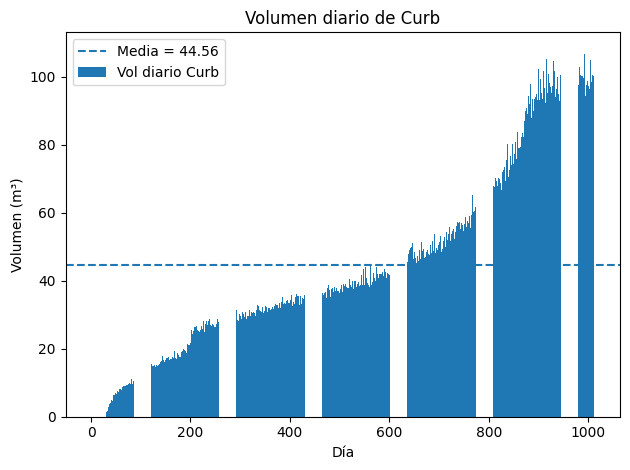

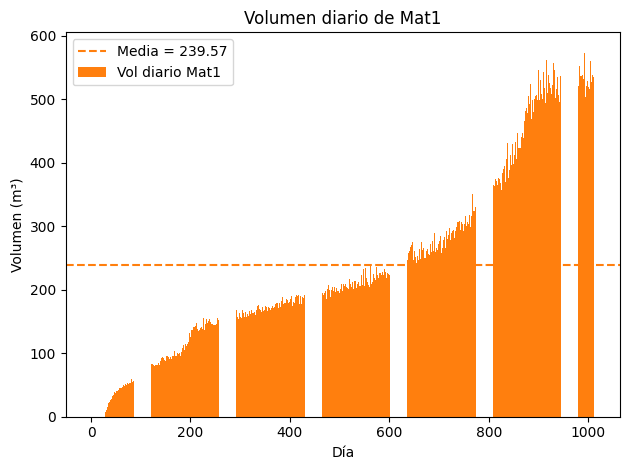

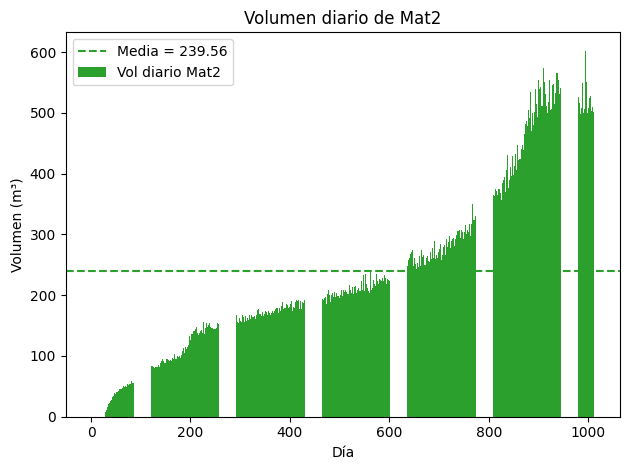

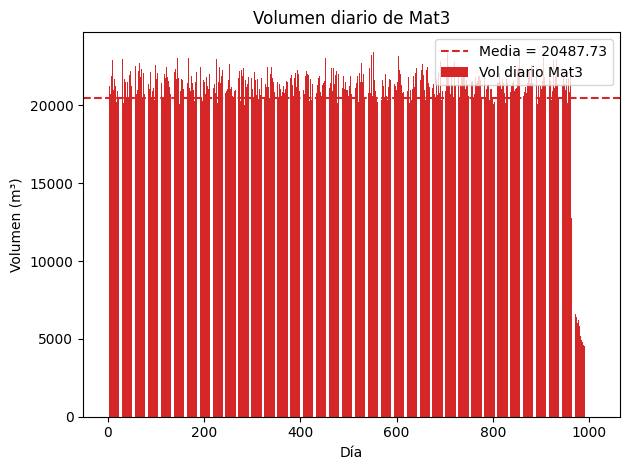

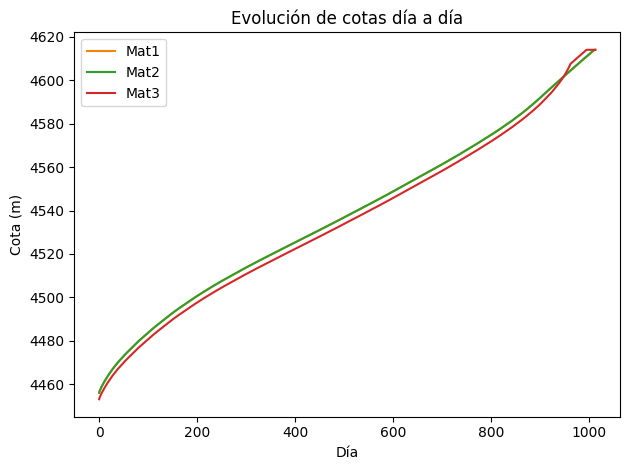

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Leer datos
volumes = pd.read_csv("daily_volumes.csv")
heights = pd.read_csv("daily_heights.csv")

# Mapeo de colores consistente
colors = {
    "Curb":   "tab:blue",
    "Mat1":   "tab:orange",
    "Mat2":   "tab:green",
    "Mat3":   "tab:red",
}

# Volúmenes diarios (barras) + media (línea discontinua) — una figura por material
for m, color in colors.items():
    col_vol = f"Vol_{m}"
    plt.figure()
    # Barras
    plt.bar(volumes["Dia"], volumes[col_vol], color=color, label=f"Vol diario {m}")
    # Media
    mean_val = volumes[col_vol].mean()
    plt.axhline(mean_val, linestyle='--', color=color,
                label=f"Media = {mean_val:.2f}")
    plt.title(f"Volumen diario de {m}")
    plt.xlabel("Día")
    plt.ylabel("Volumen (m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Evolución de cotas (líneas simples, sin marcadores) — solo Mat1, Mat2 y Mat3
plt.figure()
for m in ["Mat1", "Mat2", "Mat3"]:
    col_h = f"H_{m}"
    plt.plot(heights["Dia"], heights[col_h],
             color=colors[m],
             linestyle='-',
             label=m)
plt.title("Evolución de cotas día a día")
plt.xlabel("Día")
plt.ylabel("Cota (m)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
import numpy as np
import pandas as pd
from typing import Tuple, List

# ==========================
# Configuración
# ==========================
DATA_FILE   = "data.csv"
SEED        = 42
STOCHASTIC  = True  # True = Monte Carlo (PERT), False = determinista (most_likely)

# Materiales y mapeo de columnas del CSV
MATERIALS = ["curb", "mat1", "mat2", "mat3"]
CSV_COLS  = {"curb": "Curb", "mat1": "Material1", "mat2": "Material2", "mat3": "Material3"}
IDX       = {m: i for i, m in enumerate(MATERIALS)}
N         = len(MATERIALS)

# Tensor 3D de restricciones: constraints[i,j,0]=min ; constraints[i,j,1]=max
# Restricción sobre (hi - hj)
CONSTRAINTS = np.full((N, N, 2), np.nan)
CONSTRAINTS[IDX['curb'], IDX['mat1'], :] = [-1.10, -0.55]  # curb 0.55..1.10 m por debajo de mat1
CONSTRAINTS[IDX['mat1'], IDX['mat2'], :] = [-1.10,  0.00]  # mat1 0..1.10 m por debajo de mat2
CONSTRAINTS[IDX['mat3'], IDX['mat2'], :] = [-3.00,  3.00]  # mat3 ±3 m respecto de mat2

# Parámetros PERT (m³/día)
PERF_PARAMS = {
    "curb": {"optimistic": 200,   "most_likely": 170,  "pessimistic": 140},
    "mat1": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat2": {"optimistic": 620,   "most_likely": 520,  "pessimistic": 490},
    "mat3": {"optimistic": 24000, "most_likely": 21000,"pessimistic": 20000},
}

# ==========================
# Carga de datos: incremental -> acumulado -> normalizado
# ==========================
def load_data(path: str = DATA_FILE) -> pd.DataFrame:
    """
    Carga CSV, valida columnas, ordena por Cota ascendente y
    convierte SIEMPRE volúmenes por cota (incrementales) a acumulados (cumsum), sin comprobaciones.
    """
    expected = {"Cota", "Curb", "Material1", "Material2", "Material3"}
    df = pd.read_csv(path, delimiter=";")
    if not expected.issubset(df.columns):
        raise ValueError(f"{path} debe contener las columnas: {expected}")

    df = df.sort_values("Cota").reset_index(drop=True)

    # Incremental -> acumulado
    for m, col in CSV_COLS.items():
        s = pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        df[col] = np.cumsum(s)

    return df

def build_interpolators(df: pd.DataFrame):
    """
    Interpoladores NORMALIZADOS:
    - vnorm_at_h(m, h): volumen acumulado *normalizado* a la cota h (0 en Hmin)
    - h_at_vnorm(m, v): cota para un volumen acumulado *normalizado* v
    """
    H = pd.to_numeric(df["Cota"], errors="coerce").to_numpy(dtype=float)
    Vabs = {m: pd.to_numeric(df[CSV_COLS[m]], errors="coerce").fillna(0.0).to_numpy(dtype=float)
            for m in MATERIALS}

    Hmin, Hmax = float(H[0]), float(H[-1])
    V0 = {m: Vabs[m][0] for m in MATERIALS}
    Vnorm = {m: Vabs[m] - V0[m] for m in MATERIALS}
    Vnorm_max = {m: float(Vnorm[m][-1]) for m in MATERIALS}

    def vnorm_at_h(m: str, h: float) -> float:
        return float(np.interp(h, H, Vnorm[m], left=Vnorm[m][0], right=Vnorm[m][-1]))

    def h_at_vnorm(m: str, v: float) -> float:
        v_clamped = np.clip(v, 0.0, Vnorm_max[m])
        return float(np.interp(v_clamped, Vnorm[m], H, left=Hmin, right=Hmax))

    return (vnorm_at_h, h_at_vnorm, Hmin, Hmax, Vnorm_max)

# ==========================
# PERT y muestreo de rendimiento
# ==========================
def compute_pert_alpha_beta(opt: float, mode: float, pes: float) -> Tuple[float, float]:
    alpha = 1.0 + 4.0 * (mode - opt) / (pes - opt)
    beta  = 1.0 + 4.0 * (pes - mode) / (pes - opt)
    return alpha, beta

def sample_performance(material: str, rng: np.random.Generator, stochastic: bool = True) -> float:
    p = PERF_PARAMS[material]
    if not stochastic:
        return float(p["most_likely"])
    a, b = compute_pert_alpha_beta(p["optimistic"], p["most_likely"], p["pessimistic"])
    x = rng.beta(a, b)
    return float(p["optimistic"] + x * (p["pessimistic"] - p["optimistic"]))

# ==========================
# Proyección SOLO HACIA ABAJO (no aumenta volúmenes)
# ==========================
def enforce_constraints_down(
    heights_prop: np.ndarray,
    heights_floor: np.ndarray,
    constraints: np.ndarray,
    hmin: float,
    hmax: float,
    max_iters: int = 80,
    tol: float = 1e-8,
) -> np.ndarray:
    """
    Proyecta cotas para cumplir el tensor SIN NUNCA SUPERAR las cotas propuestas del día.
    Garantiza: heights_floor <= h_end <= heights_prop.
    Reglas:
      - Si (hi - hj) < min_ij -> bajo h_j.
      - Si (hi - hj) > max_ij -> bajo h_i.
    """
    h = heights_prop.copy()
    # Respetar piso (ayer) y techo (propuesto)
    h = np.clip(h, np.maximum(heights_floor, hmin), np.minimum(heights_prop, hmax))

    # Lista de restricciones activas
    pairs: List[Tuple[int, int, float, float]] = []
    for i in range(N):
        for j in range(N):
            mn, mx = constraints[i, j, 0], constraints[i, j, 1]
            if not (np.isnan(mn) and np.isnan(mx)):
                if np.isnan(mn): mn = -np.inf
                if np.isnan(mx): mx =  np.inf
                pairs.append((i, j, mn, mx))

    for _ in range(max_iters):
        changed = False
        h_prev = h.copy()

        for (i, j, mn, mx) in pairs:
            dij = h[i] - h[j]

            # Violación del mínimo: i demasiado bajo respecto a j -> BAJO j
            if dij < mn:
                target_j = h[i] - mn  # mover j hacia abajo
                # no subir j por encima de h[j]; asegurar no bajar de piso
                new_j = np.clip(target_j, heights_floor[j], h[j])  # solo bajar
                if new_j < h[j] - tol:
                    h[j] = new_j
                    changed = True

            # Violación del máximo: i demasiado alto respecto a j -> BAJO i
            elif dij > mx:
                target_i = h[j] + mx  # mover i hacia abajo
                new_i = np.clip(target_i, heights_floor[i], h[i])  # solo bajar
                if new_i < h[i] - tol:
                    h[i] = new_i
                    changed = True

        # Asegurar cotas dentro de [floor, prop]
        h = np.clip(h, heights_floor, heights_prop)

        if not changed or np.linalg.norm(h - h_prev, ord=np.inf) < tol:
            break

    return h

# ==========================
# Simulación diaria (con límites de no-superación de producción)
# ==========================
def simulate_daily(
    df: pd.DataFrame,
    constraints: np.ndarray,
    stochastic: bool = True,
    seed: int = SEED,
    max_days: int = 100000,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Devuelve:
      - heights_df: Dia, H_Curb, H_Mat1, H_Mat2, H_Mat3
      - volumes_df: Dia, Vol_Curb, Vol_Mat1, Vol_Mat2, Vol_Mat3  (volúmenes DEL DÍA)
    """
    rng = np.random.default_rng(seed)
    vnorm_at_h, h_at_vnorm, Hmin, Hmax, Vnorm_max = build_interpolators(df)

    # Estado inicial
    h = np.array([Hmin] * N, dtype=float)  # cotas de ayer (día -1)
    v = np.zeros(N, dtype=float)           # vol acumulado normalizado de ayer

    heights_rows = []
    volumes_rows = []

    day = 0
    while day < max_days:
        if np.all(h >= Hmax - 1e-9):
            break

        # 1) Rendimientos propuestos y remanente
        prod = np.array([sample_performance(m, rng, stochastic) for m in MATERIALS], dtype=float)
        remaining = np.array([Vnorm_max[m] - v[IDX[m]] for m in MATERIALS], dtype=float)
        prod = np.maximum(0.0, np.minimum(prod, remaining))

        # 2) Volumen propuesto del día -> volumen acumulado propuesto (normalizado)
        v_prop = v + prod

        # 3) Cotas propuestas por inversión de V_norm(h)
        h_prop = np.array([h_at_vnorm(m, v_prop[IDX[m]]) for m in MATERIALS], dtype=float)
        h_prop = np.clip(h_prop, Hmin, Hmax)

        # 4) Proyección SOLO hacia abajo para cumplir tensor (no aumentar volúmenes)
        h_end = enforce_constraints_down(
            heights_prop=h_prop,
            heights_floor=h,        # no podemos bajar de la cota de ayer
            constraints=CONSTRAINTS,
            hmin=Hmin,
            hmax=Hmax,
        )

        # 5) Volúmenes acumulados reales al final del día
        v_end = np.array([vnorm_at_h(m, h_end[IDX[m]]) for m in MATERIALS], dtype=float)

        # 6) Volumen DEL DÍA real (no puede exceder prod por construcción)
        daily_vol = v_end - v
        daily_vol = np.maximum(daily_vol, 0.0)
        # Protección numérica: asegurar no superar producción propuesta
        daily_vol = np.minimum(daily_vol, prod + 1e-9)

        # 7) Registro
        heights_rows.append({
            "Dia": day,
            "H_Curb": h_end[IDX["curb"]],
            "H_Mat1": h_end[IDX["mat1"]],
            "H_Mat2": h_end[IDX["mat2"]],
            "H_Mat3": h_end[IDX["mat3"]],
        })
        volumes_rows.append({
            "Dia": day,
            "Vol_Curb": daily_vol[IDX["curb"]],
            "Vol_Mat1": daily_vol[IDX["mat1"]],
            "Vol_Mat2": daily_vol[IDX["mat2"]],
            "Vol_Mat3": daily_vol[IDX["mat3"]],
        })

        # 8) Avance al día siguiente
        h = h_end
        v = v + daily_vol  # nota: usamos el volumen DEL DÍA realmente ejecutado
        day += 1

        # Corte de seguridad si no hay avance
        if np.all(daily_vol < 1e-9):
            print("Sin avance adicional; finalizando anticipadamente.")
            break

    heights_df = pd.DataFrame(heights_rows)
    volumes_df = pd.DataFrame(volumes_rows)
    return heights_df, volumes_df

# ==========================
# Main
# ==========================
def main():
    np.random.seed(SEED)
    df = load_data(DATA_FILE)

    heights_df, volumes_df = simulate_daily(
        df=df,
        constraints=CONSTRAINTS,
        stochastic=STOCHASTIC,
        seed=SEED,
    )
    heights_df.to_csv("daily_heights.csv", index=False)
    volumes_df.to_csv("daily_volumes.csv", index=False)
    print("Archivos escritos: daily_heights.csv, daily_volumes.csv")

if __name__ == "__main__":
    main()


Sin avance adicional; finalizando anticipadamente.
Archivos escritos: daily_heights.csv, daily_volumes.csv


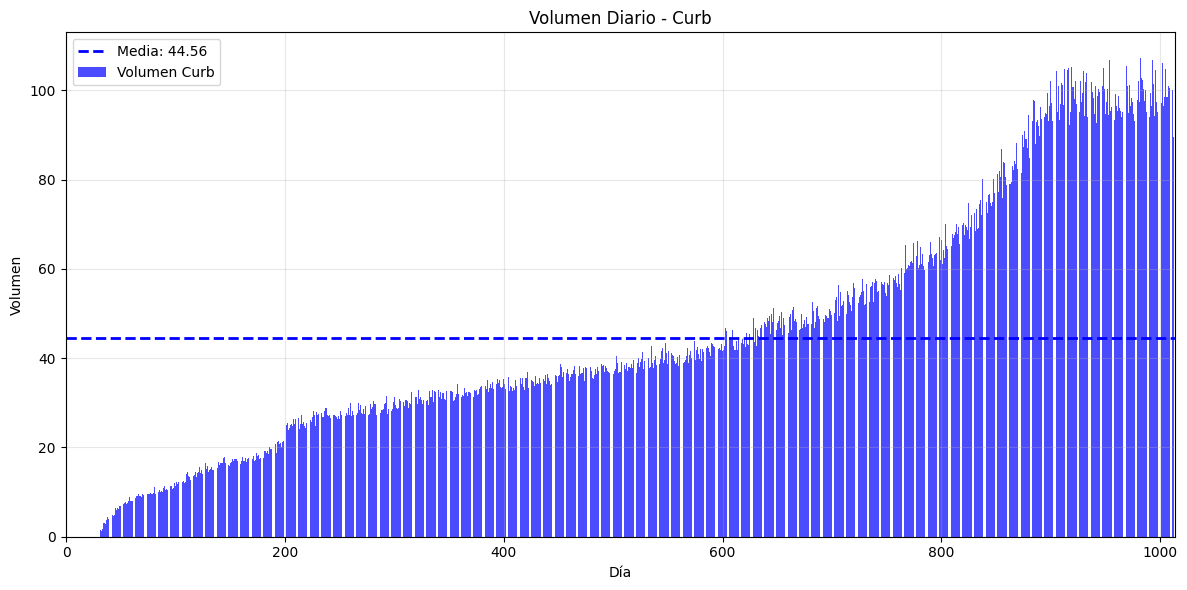

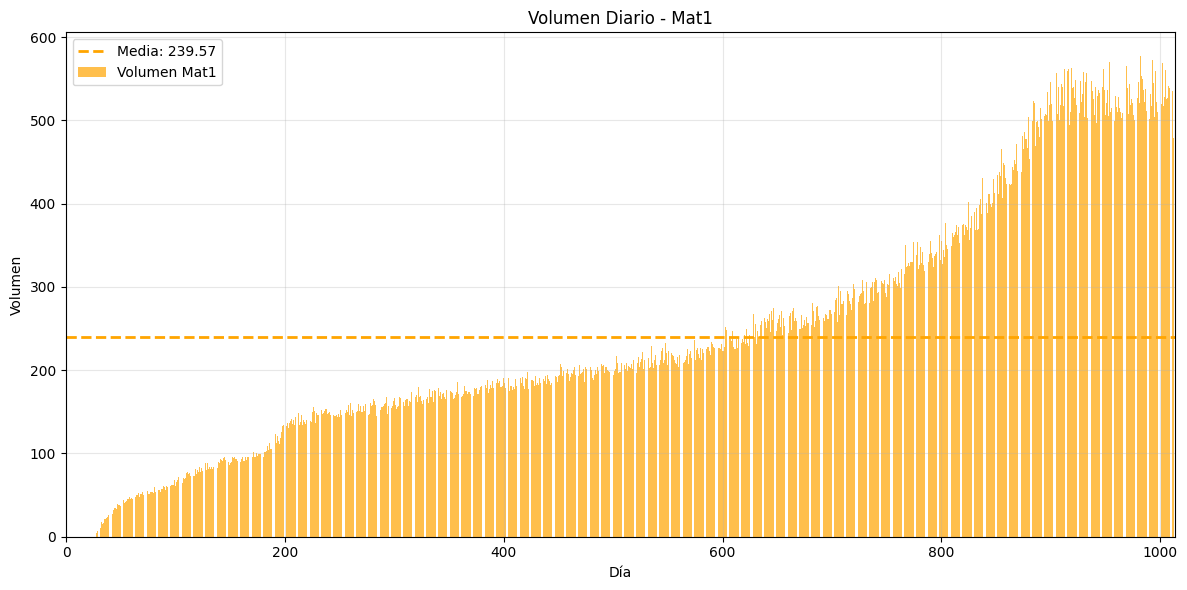

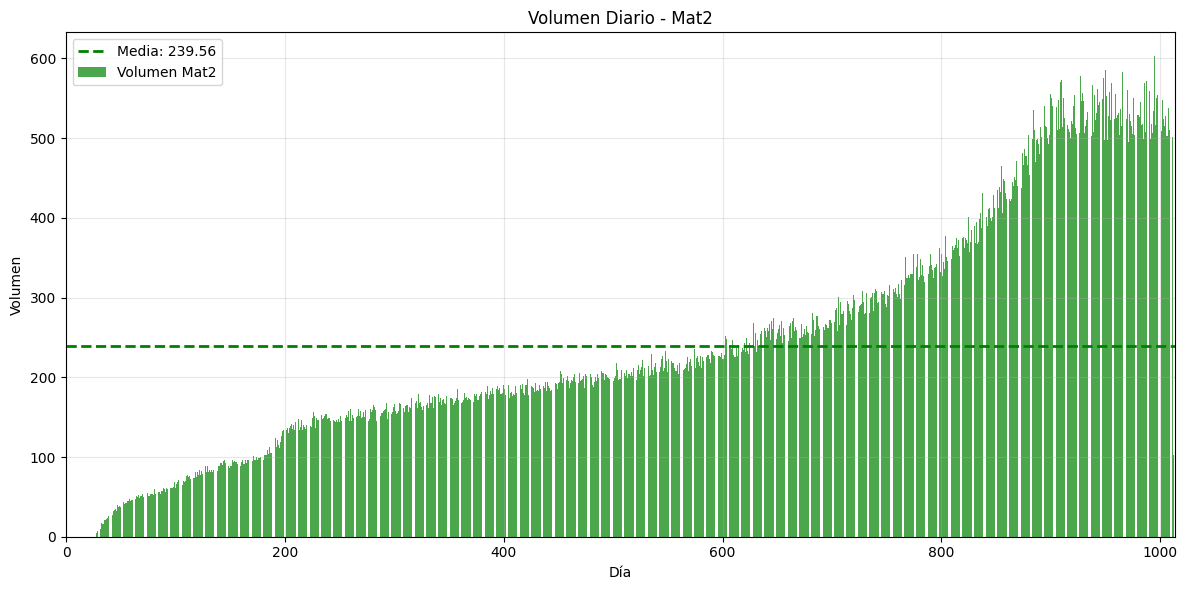

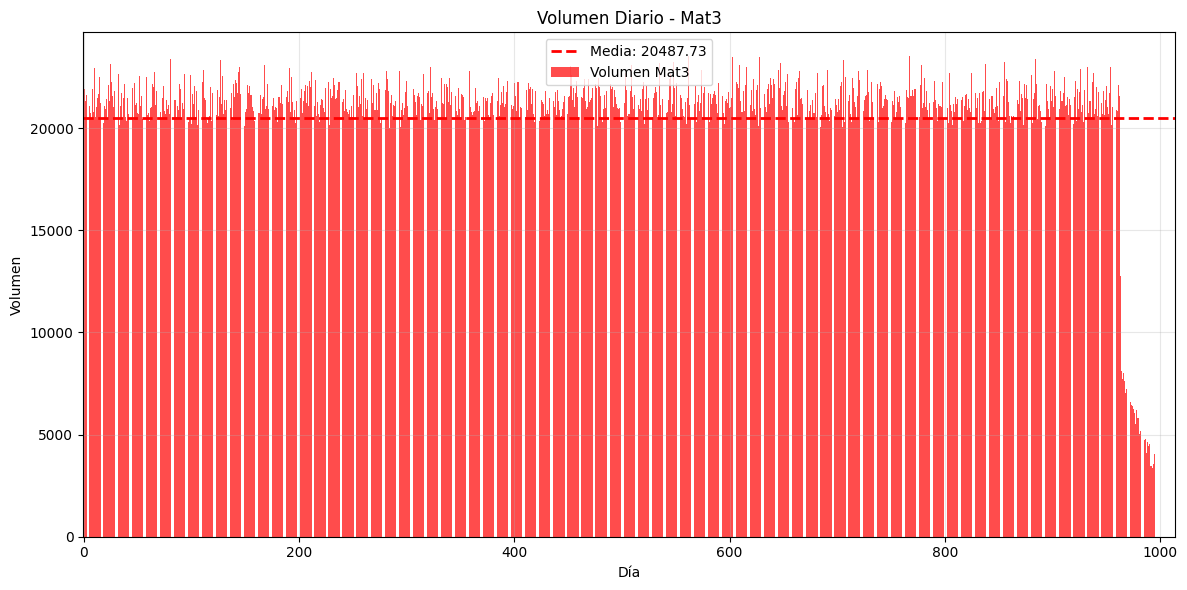

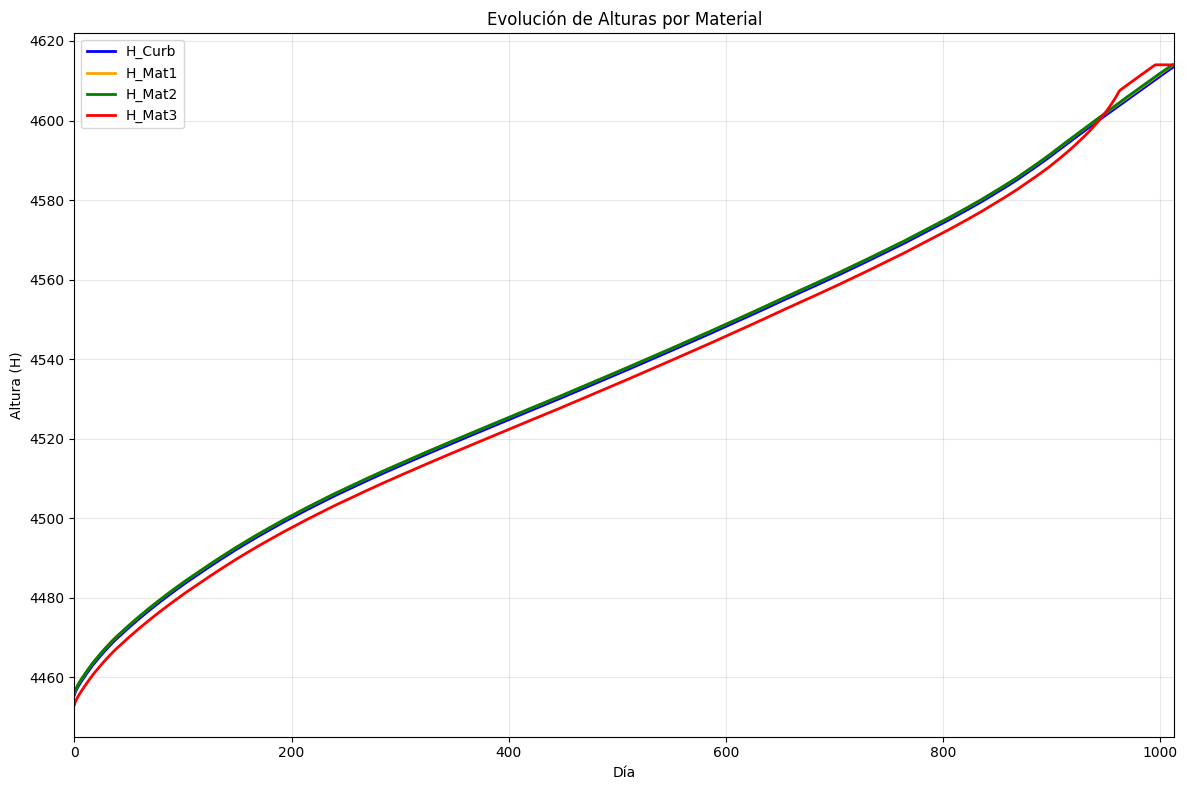

=== ESTADÍSTICAS DE VOLÚMENES ===
               Dia     Vol_Curb     Vol_Mat1     Vol_Mat2      Vol_Mat3
count  1014.000000  1014.000000  1014.000000  1014.000000   1014.000000
mean    506.500000    44.564588   239.571497   239.557108  20487.725213
std     292.860888    27.632805   147.233928   147.886680   3970.212838
min       0.000000     0.000000     0.000000     0.000000      0.000000
25%     253.250000    27.531895   149.525604   149.430237  20727.878413
50%     506.500000    38.024157   204.048623   204.005083  21258.049663
75%     759.750000    57.775201   310.412966   308.477829  21818.368268
max    1013.000000   107.644697   576.819353   602.640765  23510.099558

=== ESTADÍSTICAS DE ALTURAS ===
               Dia       H_Curb       H_Mat1       H_Mat2       H_Mat3
count  1014.000000  1014.000000  1014.000000  1014.000000  1014.000000
mean    506.500000  4537.716829  4538.266829  4538.279167  4535.656077
std     292.860888    39.749896    39.749896    39.771058    40.438617
m

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Leer los archivos CSV
daily_volumes = pd.read_csv('daily_volumes.csv')
daily_heights = pd.read_csv('daily_heights.csv')

# Definir colores consistentes para cada material
colors = {
    'Curb': 'blue',
    'Mat1': 'orange',
    'Mat2': 'green',
    'Mat3': 'red'
}

# Configurar el estilo de matplotlib
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Generar figuras de barras para cada material con línea de media
materials = ['Curb', 'Mat1', 'Mat2', 'Mat3']

for material in materials:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Columna de volumen correspondiente
    vol_col = f'Vol_{material}'

    # Crear gráfico de barras
    bars = ax.bar(daily_volumes['Dia'], daily_volumes[vol_col],
                  color=colors[material], alpha=0.7,
                  label=f'Volumen {material}')

    # Calcular y mostrar la media
    mean_vol = daily_volumes[vol_col].mean()
    ax.axhline(y=mean_vol, color=colors[material], linestyle='--',
               linewidth=2, label=f'Media: {mean_vol:.2f}')

    # Configurar etiquetas y título
    ax.set_xlabel('Día')
    ax.set_ylabel('Volumen')
    ax.set_title(f'Volumen Diario - {material}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Ajustar márgenes del eje X
    ax.set_xlim(-0.5, len(daily_volumes) - 0.5)

    plt.tight_layout()
    plt.show()

# 2. Generar figura de líneas para las alturas
fig, ax = plt.subplots(figsize=(12, 8))

# Graficar cada serie de altura
for material in materials:
    height_col = f'H_{material}'
    ax.plot(daily_heights['Dia'], daily_heights[height_col],
            color=colors[material], linewidth=2,
            label=f'H_{material}')

# Configurar etiquetas y título
ax.set_xlabel('Día')
ax.set_ylabel('Altura (H)')
ax.set_title('Evolución de Alturas por Material')
ax.legend()
ax.grid(True, alpha=0.3)

# Ajustar márgenes del eje X
ax.set_xlim(0, len(daily_heights) - 1)

plt.tight_layout()
plt.show()

# Mostrar estadísticas básicas
print("=== ESTADÍSTICAS DE VOLÚMENES ===")
print(daily_volumes.describe())
print("\n=== ESTADÍSTICAS DE ALTURAS ===")
print(daily_heights.describe())

# Mostrar medias de volúmenes
print("\n=== MEDIAS DE VOLÚMENES POR MATERIAL ===")
for material in materials:
    vol_col = f'Vol_{material}'
    mean_vol = daily_volumes[vol_col].mean()
    print(f"{material}: {mean_vol:.2f}")

=== GRÁFICO 1: Marcadores desfasados cada 50 días ===


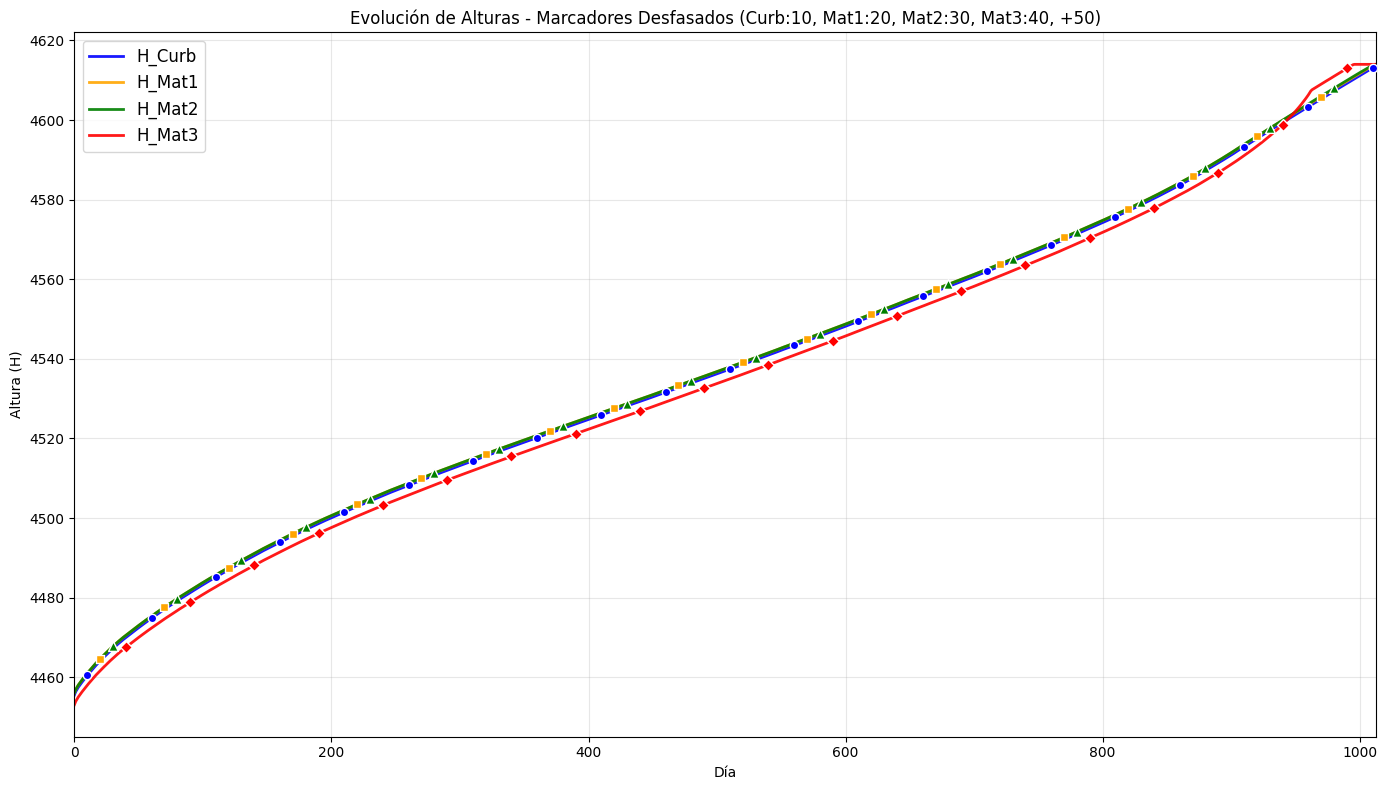


=== GRÁFICO 2: Diferencias respecto a H_Curb (referencia) ===


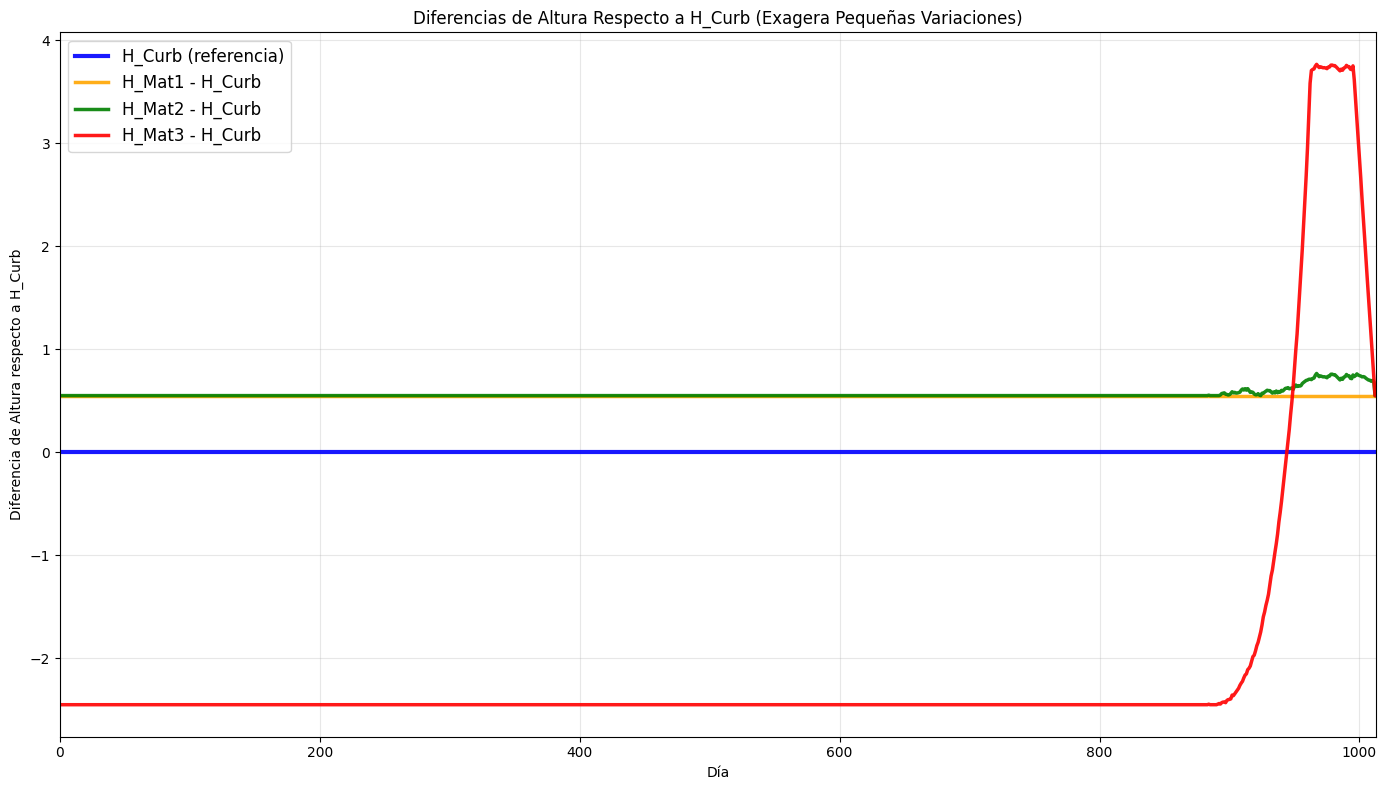


=== GRÁFICO 3: Estilos diferenciados + escala ultra-expandida ===


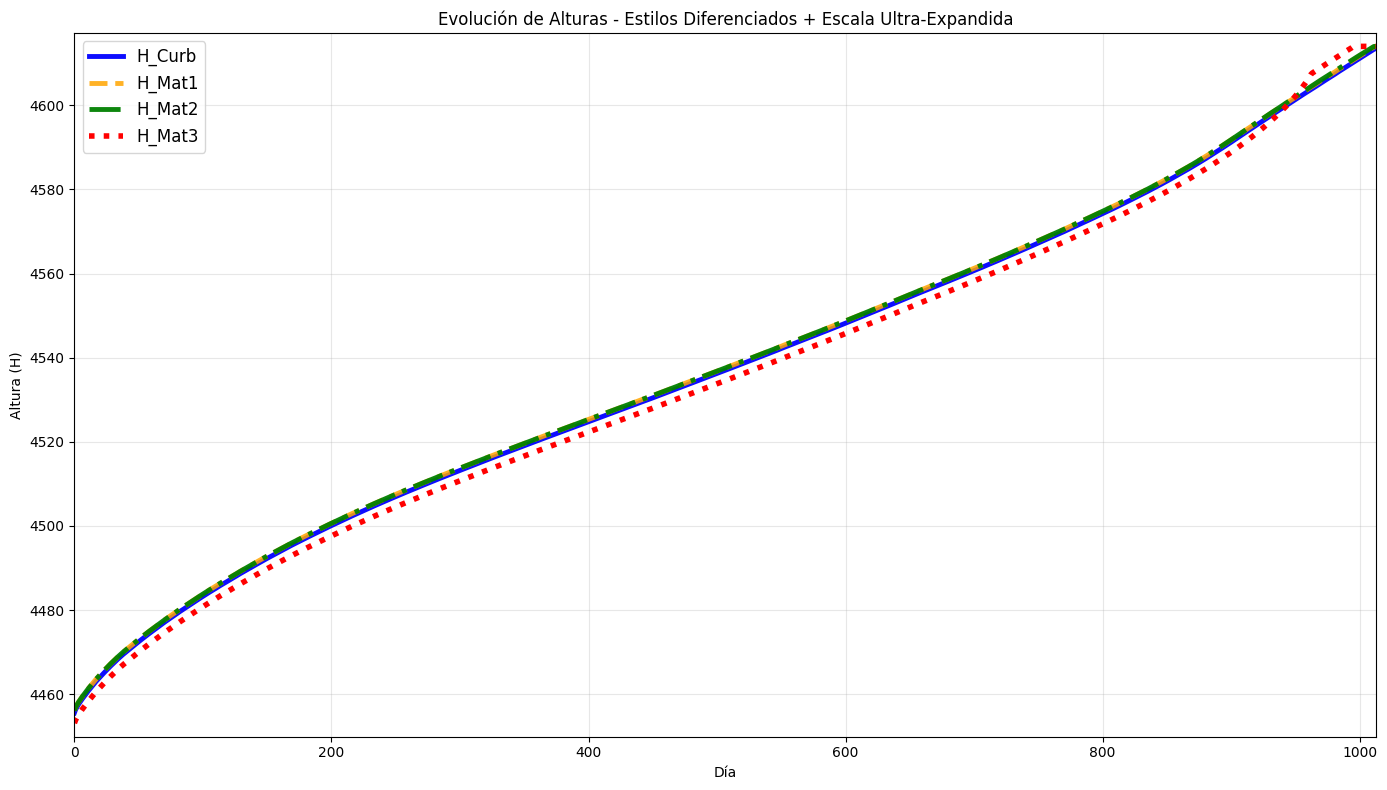


=== RESUMEN DE LOS TRES GRÁFICOS ===
1. MARCADORES DESFASADOS: Cada material tiene marcadores que inician en días diferentes
   - Curb: marcadores en días 10, 60, 110, 160...
   - Mat1: marcadores en días 20, 70, 120, 170...
   - Mat2: marcadores en días 30, 80, 130, 180...
   - Mat3: marcadores en días 40, 90, 140, 190...

2. DIFERENCIAS vs H_CURB: Exagera las pequeñas variaciones usando Curb como referencia

3. ESTILOS DIFERENCIADOS: Usa diferentes tipos de línea con escala ultra-expandida
   - Curb: línea sólida
   - Mat1: línea discontinua
   - Mat2: línea punto-raya
   - Mat3: línea punteada


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Leer el archivo CSV de alturas
daily_heights = pd.read_csv('daily_heights.csv')

# Definir colores consistentes
colors = {
    'Curb': 'blue',
    'Mat1': 'orange',
    'Mat2': 'green',
    'Mat3': 'red'
}

materials = ['Curb', 'Mat1', 'Mat2', 'Mat3']

# ============================================================================
# GRÁFICO 1: MARCADORES DESFASADOS (cada 50 días pero iniciando en diferente punto)
# ============================================================================

print("=== GRÁFICO 1: Marcadores desfasados cada 50 días ===")
fig, ax = plt.subplots(figsize=(14, 8))

markers = ['o', 's', '^', 'D']
marker_sizes = [6, 6, 7, 6]
# Desfases: Curb=10, Mat1=20, Mat2=30, Mat3=40, luego cada 50
start_offsets = [10, 20, 30, 40]

for i, material in enumerate(materials):
    height_col = f'H_{material}'

    # Crear lista de posiciones de marcadores desfasados
    marker_positions = list(range(start_offsets[i], len(daily_heights), 50))

    ax.plot(daily_heights['Dia'], daily_heights[height_col],
            color=colors[material], linewidth=2,
            label=f'H_{material}', alpha=0.9)

    # Agregar marcadores en posiciones específicas
    if marker_positions:  # Verificar que hay posiciones válidas
        valid_positions = [pos for pos in marker_positions if pos < len(daily_heights)]
        if valid_positions:
            ax.scatter(daily_heights['Dia'].iloc[valid_positions],
                      daily_heights[height_col].iloc[valid_positions],
                      color=colors[material], marker=markers[i],
                      s=marker_sizes[i]**2, zorder=5, edgecolors='white', linewidths=1)

# Escala expandida
y_min = daily_heights[['H_Curb', 'H_Mat1', 'H_Mat2', 'H_Mat3']].min().min()
y_max = daily_heights[['H_Curb', 'H_Mat1', 'H_Mat2', 'H_Mat3']].max().max()
margin = (y_max - y_min) * 0.05
ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel('Día')
ax.set_ylabel('Altura (H)')
ax.set_title('Evolución de Alturas - Marcadores Desfasados (Curb:10, Mat1:20, Mat2:30, Mat3:40, +50)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(daily_heights) - 1)
plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 2: DIFERENCIAS RESPECTO A H_CURB
# ============================================================================

print("\n=== GRÁFICO 2: Diferencias respecto a H_Curb (referencia) ===")
fig, ax = plt.subplots(figsize=(14, 8))

reference_col = 'H_Curb'
ax.axhline(y=0, color=colors['Curb'], linewidth=3,
           label='H_Curb (referencia)', alpha=0.9, linestyle='-')

for material in ['Mat1', 'Mat2', 'Mat3']:
    height_col = f'H_{material}'
    differences = daily_heights[height_col] - daily_heights[reference_col]
    ax.plot(daily_heights['Dia'], differences,
            color=colors[material], linewidth=2.5,
            label=f'H_{material} - H_Curb', alpha=0.9)

ax.set_xlabel('Día')
ax.set_ylabel('Diferencia de Altura respecto a H_Curb')
ax.set_title('Diferencias de Altura Respecto a H_Curb (Exagera Pequeñas Variaciones)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(daily_heights) - 1)
plt.tight_layout()
plt.show()

# ============================================================================
# GRÁFICO 3: ESTILOS + TRANSPARENCIAS + ESCALA ULTRA-EXPANDIDA
# ============================================================================

print("\n=== GRÁFICO 3: Estilos diferenciados + escala ultra-expandida ===")
fig, ax = plt.subplots(figsize=(14, 8))

line_styles = ['-', '--', '-.', ':']
alphas = [0.95, 0.85, 0.95, 1.0]
line_widths = [3.5, 3.5, 3.5, 4]

for i, material in enumerate(materials):
    height_col = f'H_{material}'
    ax.plot(daily_heights['Dia'], daily_heights[height_col],
            color=colors[material], linestyle=line_styles[i],
            linewidth=line_widths[i], alpha=alphas[i],
            label=f'H_{material}')

# Escala ultra-expandida (solo 2% de margen)
y_min = daily_heights[['H_Curb', 'H_Mat1', 'H_Mat2', 'H_Mat3']].min().min()
y_max = daily_heights[['H_Curb', 'H_Mat1', 'H_Mat2', 'H_Mat3']].max().max()
margin = (y_max - y_min) * 0.02
ax.set_ylim(y_min - margin, y_max + margin)

ax.set_xlabel('Día')
ax.set_ylabel('Altura (H)')
ax.set_title('Evolución de Alturas - Estilos Diferenciados + Escala Ultra-Expandida')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(daily_heights) - 1)
plt.tight_layout()
plt.show()

print("\n=== RESUMEN DE LOS TRES GRÁFICOS ===")
print("1. MARCADORES DESFASADOS: Cada material tiene marcadores que inician en días diferentes")
print("   - Curb: marcadores en días 10, 60, 110, 160...")
print("   - Mat1: marcadores en días 20, 70, 120, 170...")
print("   - Mat2: marcadores en días 30, 80, 130, 180...")
print("   - Mat3: marcadores en días 40, 90, 140, 190...")
print()
print("2. DIFERENCIAS vs H_CURB: Exagera las pequeñas variaciones usando Curb como referencia")
print()
print("3. ESTILOS DIFERENCIADOS: Usa diferentes tipos de línea con escala ultra-expandida")
print("   - Curb: línea sólida")
print("   - Mat1: línea discontinua")
print("   - Mat2: línea punto-raya")
print("   - Mat3: línea punteada")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_mc_schedule(
    df: pd.DataFrame,
    constraints: np.ndarray,
    n_iter: int = 10_000,
    conf: float = 0.95,          # nivel de confianza (percentil), e.g., 0.95 => P95
    stochastic: bool = True,     # True = Monte Carlo (PERT), False = determinista (most_likely)
    base_seed: int = 42,
    csv_path: str = "mc_days.csv",
    show_plot: bool = True
):
    """
    Ejecuta N iteraciones de la simulación de planificación diaria y guarda:
      - CSV con columnas: ['iteracion', 'max_dias'].
      - Grafica histograma de 'max_dias' y marca el percentil 'conf'.

    Requiere que tengas definida la función:
        heights_df, volumes_df = simulate_daily(df, constraints, stochastic=True/False, seed=...)
    """
    rows = []
    for k in range(n_iter):
        seed = base_seed + k
        heights_df, _ = simulate_daily(df, constraints, stochastic=stochastic, seed=seed)
        max_dias = 0 if heights_df.empty else int(heights_df["Dia"].max()) + 1
        rows.append((k + 1, max_dias))

    res = pd.DataFrame(rows, columns=["iteracion", "max_dias"])
    res.to_csv(csv_path, index=False)

    p_val = float(np.quantile(res["max_dias"].to_numpy(), conf))
    p_days = int(np.ceil(p_val))

    if show_plot:
        plt.figure()
        plt.hist(res["max_dias"], bins="auto")
        plt.axvline(p_val, linestyle="--")
        plt.title(f"Distribución de días totales (n={n_iter})\nPercentil {int(conf*100)}% = {p_days} días")
        plt.xlabel("Días para finalizar")
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

    return res, p_days


Se han truncado las últimas 5000 líneas del flujo de salida.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional; finalizando anticipadamente.
Sin avance adicional;

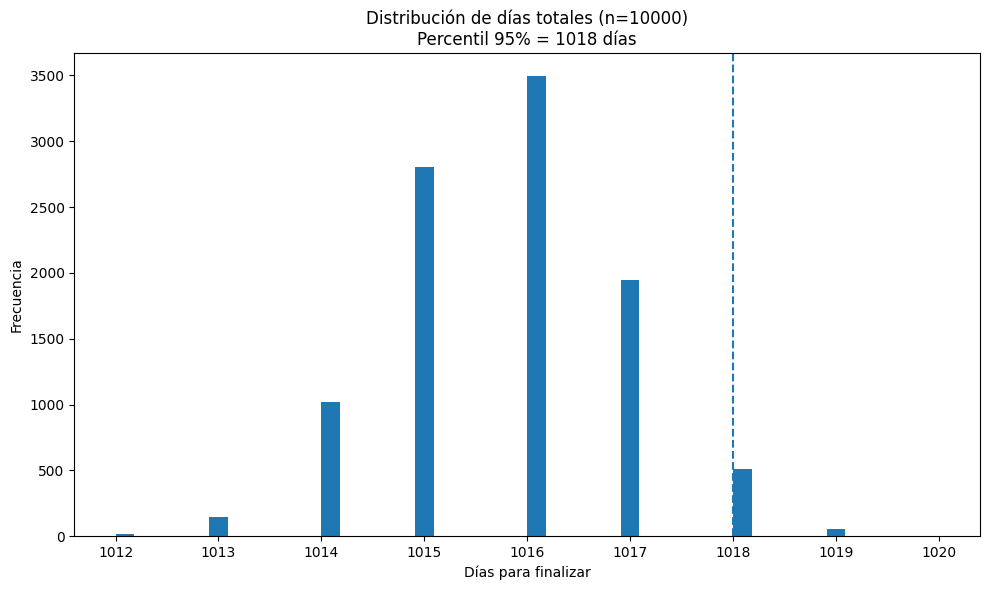

Confiabilidad 95% ⇒ terminaría en 1018 días


In [9]:
df = load_data(DATA_FILE)  # tu loader
constraints = CONSTRAINTS  # tu tensor
res, p95_days = run_mc_schedule(df, constraints, n_iter=10000, conf=0.95, stochastic=True,
                                base_seed=42, csv_path="mc_days.csv", show_plot=True)
print("Confiabilidad 95% ⇒ terminaría en", p95_days, "días")
